In [6]:
import os
import sys
import time
import random
import yaml
import warnings
from pathlib import Path

import darkfield
import darkfield.mmmUtils_v2 as mu
import darkfield.rossendorfer_farbenliste as rofl
import darkfield.VIBE as vibe

import numpy as np
from bash_config import write_bash

from LightPipes import *
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.colors as colors
from matplotlib import cm
from matplotlib.ticker import LinearLocator
from matplotlib.colors import LogNorm
from importlib import reload

In [7]:
###################### PLOT DEFAULT PARAMETERS #####################
plt.rc('font',   size     =17)          # controls default text sizes
plt.rc('axes',   titlesize=17)  # fontsize of the axes title
plt.rc('axes',   labelsize=17)          # fontsize of the x and y labels
plt.rc('xtick',  labelsize=19) # fontsize of the tick labels
plt.rc('ytick',  labelsize=19) # fontsize of the tick labels
plt.rc('legend', fontsize =14)          # legend fontsize

Loading: /home/yu79deg/darkfield_p5438/Aime/pickles/VB_23_figs.pickle
Loading scaling info: /home/yu79deg/darkfield_p5438/Aime/pickles/VB_23_res.pickle
dict_keys(['beam_shaper_main', 'O1_main', 'CRL4a_main', 'flow_000_-0.50_main', 'flow_001_-0.44_main', 'flow_002_-0.38_main', 'flow_003_-0.32_main', 'flow_004_-0.26_main', 'flow_005_-0.20_main', 'flow_006_-0.14_main', 'flow_007_-0.08_main', 'flow_008_-0.02_main', 'TCC_main', 'TCC_VB_parr', 'TCC_VB_perp', 'flow_009_0.04_main', 'flow_009_0.04_VB_parr', 'flow_009_0.04_VB_perp', 'flow_010_0.10_main', 'flow_010_0.10_VB_parr', 'flow_010_0.10_VB_perp', 'flow_011_0.16_main', 'flow_011_0.16_VB_parr', 'flow_011_0.16_VB_perp', 'flow_012_0.22_main', 'flow_012_0.22_VB_parr', 'flow_012_0.22_VB_perp', 'flow_013_0.28_main', 'flow_013_0.28_VB_parr', 'flow_013_0.28_VB_perp', 'Det_main', 'Det_VB_parr', 'Det_VB_perp'])
Selected plane: Det_VB_perp
N=3332, dx=0.100 µm, box=333.3 µm


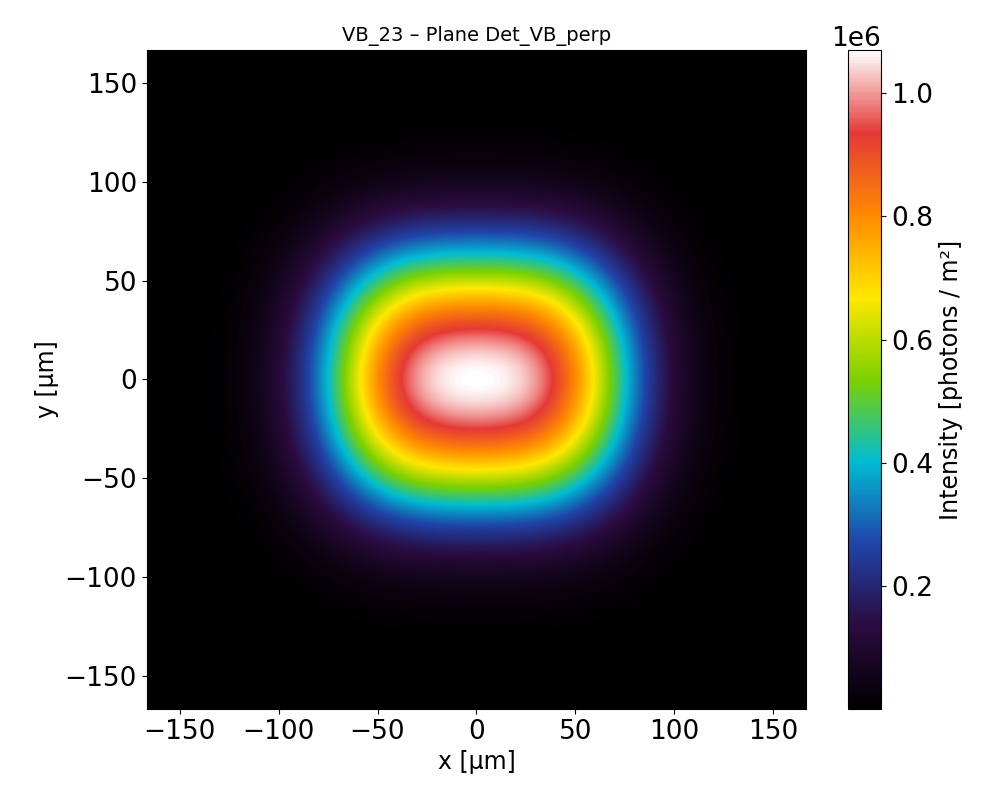

FWHM: width = 134.002599 μm, radius = 67.001299 μm (central peak)
1/e^2: width = 193.903240 μm, radius = 96.951620 μm (central peak)


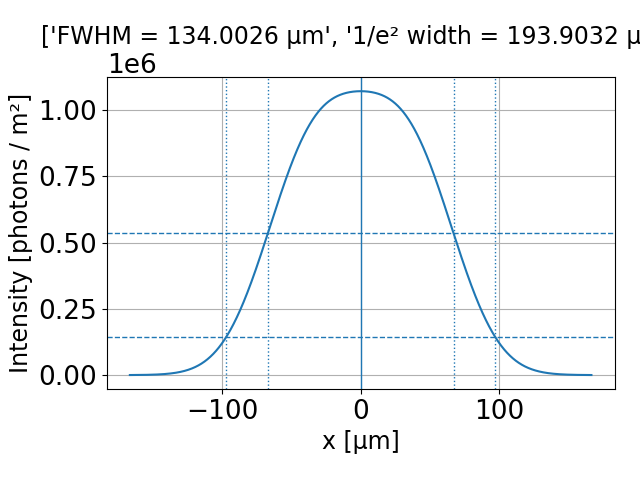

Total number of photons (over the full 2D map) = 1.642e-02 [photons / m²·m²]


In [5]:
###################### PLOT OF A GIVEN PLANE ####################
%matplotlib widget

# ----------------- USER PARAMETERS -----------------
project_dir = '/home/yu79deg/darkfield_p5438/Aime'
yaml_tag = 'VB_23'  # Simulation name
#plane_to_visualize = 'flow_733_9.99'  # Name of the plane to display
#plane_to_visualize = 'start'  # Name of the plane to display
#plane_to_visualize = 'Det_VB_parr'  # Name of the plane to display  + Channel : (main, VB_parr, VB_perp)
#plane_to_visualize = 'beam_shaper_main'  # Name of the plane to display
#plane_to_visualize = 'flow_042_1.02_VB_perp' #for VB8
#plane_to_visualize = 'flow_075_2.00_VB_perp' # for VB9
#plane_to_visualize = 'TCC_main'
#plane_to_visualize = 'beam_shaper_main'
plane_to_visualize = 'Det_VB_perp'

# ----- Choose unit -------
intensity_unit = 'photons' # Choose unit ('relative', 'photons')

# ----- Display scaling -----
use_log = False        # True → log display, False → linear
log_vmin_mode = "auto"  # "auto" or float (e.g. 1e-12) for the lowest log level

# Construct pickle file path
pickle_file = os.path.join(project_dir, 'pickles', f'{yaml_tag}_figs.pickle')
print(f"Loading: {pickle_file}")

# Load the associated _res.pickle for scaling
res_file = os.path.join(project_dir, 'pickles', f'{yaml_tag}_res.pickle')
print(f"Loading scaling info: {res_file}")
res = mu.loadPickle(res_file)
params = res[1]

scale_ph = params.get('scale_phot', 1.0)
scale_Wcm2 = params.get('scale_Wcm2', 1.0)

# Choose scale based on selected unit
if intensity_unit == 'photons':
    scale = scale_ph
    unit_label = 'photons / m²'
elif intensity_unit == 'Wcm2':
    scale = scale_Wcm2
    unit_label = 'W / m²'
else:
    scale = 1.0
    unit_label = 'a.u.'


# Load image dictionary
figs = mu.loadPickle(pickle_file)
print(figs.keys())
# Visualize selected plane

# --- Visualize exactly one plane (no loop) ---
if plane_to_visualize not in figs:
    # Helpful message if you mistyped the key
    print(f"[error] '{plane_to_visualize}' not found in figs.")
    print("Available keys (truncated):", list(figs.keys())[:20], "…")
else:
    data = figs[plane_to_visualize]      # [image, ei, propsize/ZoomFactor, z]
    img = data[0].astype(float)
    prop_size_m = float(data[2])         # physical box size (meters)
    N = img.shape[0]
    pixel_size_m = prop_size_m / N
    pixel_size_um = pixel_size_m * 1e6

    print(f"Selected plane: {plane_to_visualize}")
    print(f"N={N}, dx={pixel_size_um:.3f} µm, box={prop_size_m*1e6:.1f} µm")

    # Scale + extent
    img_scaled = img * scale
    extent = (-prop_size_m/2*1e6, prop_size_m/2*1e6,
              -prop_size_m/2*1e6, prop_size_m/2*1e6)

    # Norm (optional log)
    norm = None
    if use_log:
        pos = img_scaled > 0
        if np.any(pos):
            vmax = float(np.nanmax(img_scaled))
            vmin = (float(np.nanpercentile(img_scaled[pos], 0.1))
                    if log_vmin_mode == "auto" else float(log_vmin_mode))
            vmin = max(min(vmin, 0.99*vmax), np.finfo(float).tiny)
            from matplotlib.colors import LogNorm
            norm = LogNorm(vmin=vmin, vmax=vmax)
        else:
            print("[warn] No positive pixels, falling back to linear.")
            use_log = False

    # 2D image
    plt.figure(figsize=(10, 8))
    im = plt.imshow(img_scaled, cmap=rofl.cmap(), norm=norm, extent=extent, origin='lower', aspect='equal')
    plt.title(f'{yaml_tag} – Plane {plane_to_visualize}', fontsize=14)
    plt.xlabel('x [μm]'); plt.ylabel('y [μm]')
    plt.colorbar(im, label=f'Intensity [{unit_label}]')
    plt.tight_layout()
    plt.show()

        # --- Central horizontal cut + peak-anchored widths (FWHM & 1/e^2) ---
    Npix = img_scaled.shape[1]
    center_y = img_scaled.shape[0] // 2
    I_line = img_scaled[center_y, :].astype(float)

    # Pixel-center x coordinates (avoid 0.5-pixel bias)
    dx_um = pixel_size_um
    x0_um = -0.5 * (prop_size_m * 1e6) + 0.5 * dx_um
    x_centers_um = x0_um + np.arange(Npix) * dx_um

    # Plot the cut
    plt.figure()
    if use_log:
        plt.semilogy(x_centers_um, np.maximum(I_line, np.finfo(float).tiny))
    else:
        plt.plot(x_centers_um, I_line)
    plt.xlabel('x [μm]'); plt.ylabel(f'Intensity [{unit_label}]')
    plt.grid(True)

    # ---- peak near the center (anchor) ----
    def _central_peak_index(y):
        N = len(y)
        ic = N // 2
        def is_peak(i):
            yl = y[i-1] if i-1 >= 0 else -np.inf
            yr = y[i+1] if i+1 < N else -np.inf
            return np.isfinite(y[i]) and (y[i] >= yl) and (y[i] >= yr)
        # search outward from center for first local maximum
        for r in range(N):
            for i in (ic - r, ic + r):
                if 0 <= i < N and is_peak(i):
                    return i
        return int(np.nanargmax(y))

    i_peak = _central_peak_index(I_line)
    I0 = float(I_line[i_peak])

    if not np.isfinite(I0) or I0 <= 0:
        plt.title('Horizontal cut — central peak not found / non-positive.')
        plt.tight_layout(); plt.show()
    else:
        # -------- bracket FIRST crossings outward from the central peak --------
        def _first_brackets_from_peak(y, thr, i0):
            N = len(y)
            # Left side: walk left until falls below thr
            iL = i0
            while iL > 0 and np.isfinite(y[iL]) and y[iL] >= thr:
                iL -= 1
            if iL == 0 and y[iL] >= thr:
                return None  # never crossed
            iL_lo, iL_hi = iL, iL + 1

            # Right side: walk right until falls below thr
            iR = i0
            while iR < N - 1 and np.isfinite(y[iR]) and y[iR] >= thr:
                iR += 1
            if iR == N - 1 and y[iR] >= thr:
                return None  # never crossed
            iR_lo, iR_hi = iR - 1, iR
            return (iL_lo, iL_hi, iR_lo, iR_hi)

        # Precise root in each bracket using PCHIP + Brent; fallback to quadratic
        def _precise_crossings(x, y, thr, brackets):
            iL0, iL1, iR0, iR1 = brackets
            try:
                from scipy.interpolate import PchipInterpolator
                from scipy.optimize import brentq
                f = PchipInterpolator(x, y)
                g = lambda xx: float(f(xx) - thr)

                xL_lo, xL_hi = x[iL0], x[iL1]
                xR_lo, xR_hi = x[iR0], x[iR1]
                # nudge if exactly on threshold
                eps = 1e-15
                if g(xL_lo) == 0: xL_lo -= eps
                if g(xL_hi) == 0: xL_hi += eps
                if g(xR_lo) == 0: xR_lo -= eps
                if g(xR_hi) == 0: xR_hi += eps

                xl = brentq(g, xL_lo, xL_hi)
                xr = brentq(g, xR_lo, xR_hi)
                return float(xl), float(xr)
            except Exception:
                # quadratic fallback around each crossing
                def quad_root(i0, i1):
                    i_start = max(i0 - 1, 0)
                    i_end   = min(i1 + 1, len(x) - 1)
                    idxs = np.arange(i_start, i_end + 1)
                    if len(idxs) < 3:
                        # linear fallback
                        x0, x1 = x[i0], x[i1]
                        y0, y1 = y[i0] - thr, y[i1] - thr
                        if (y1 - y0) == 0: return x1
                        return x0 + (-y0) * (x1 - x0) / (y1 - y0)
                    coeffs = np.polyfit(x[idxs], y[idxs] - thr, 2)  # a x^2 + b x + c
                    roots = np.roots(coeffs)
                    xrts = [r.real for r in roots if abs(r.imag) < 1e-12]
                    # pick root inside the bracket
                    lo, hi = min(x[i0], x[i1]) - 1e-9, max(x[i0], x[i1]) + 1e-9
                    inb = [r for r in xrts if lo <= r <= hi]
                    if len(inb) == 0:
                        # linear fallback
                        x0, x1 = x[i0], x[i1]
                        y0, y1 = y[i0] - thr, y[i1] - thr
                        if (y1 - y0) == 0: return x1
                        return x0 + (-y0) * (x1 - x0) / (y1 - y0)
                    return inb[0]

                return quad_root(iL0, iL1), quad_root(iR0, iR1)

        # Measure widths based on CENTRAL peak height
        results = []
        for name, frac in [('FWHM', 0.5), ('1/e^2', np.exp(-2))]:
            thr = frac * I0
            br = _first_brackets_from_peak(I_line, thr, i_peak)
            if br is None:
                print(f"{name}: could not determine (no crossing from central peak).")
                continue
            xl, xr = _precise_crossings(x_centers_um, I_line, thr, br)
            width = xr - xl
            results.append((name, width, width/2.0, thr, xl, xr))
            print(f"{name}: width = {width:.6f} μm, radius = {width/2:.6f} μm (central peak)")

        # Title & guides
        title_bits = []
        for name, width, radius, *_ in results:
            if name == 'FWHM':
                title_bits.append(f"FWHM = {width:.4f} μm")
            elif name == '1/e^2':
                title_bits.append(f"1/e² width = {width:.4f} μm")
        plt.title(title_bits)

        for _, _, _, thr, xl, xr in results:
            plt.axhline(thr, linestyle='--', linewidth=1)
            plt.axvline(xl, linestyle=':', linewidth=1)
            plt.axvline(xr, linestyle=':', linewidth=1)

        # mark the central peak
        plt.axvline(x_centers_um[i_peak], linestyle='-', linewidth=1)
        plt.tight_layout(); plt.show()


    # Integrals (careful: this is sum of pixel values; multiply by pixel area for physical integral)
    sum_map = np.nansum(img_scaled)
    intensity_sum = sum_map * (pixel_size_m**2)
    print(f"Total number of photons (over the full 2D map) = {intensity_sum:.3e} [{unit_label}·m²]")



Integrated vertically over y ∈ [-19.964, 19.964] μm (400 rows, dy = 0.100 μm).


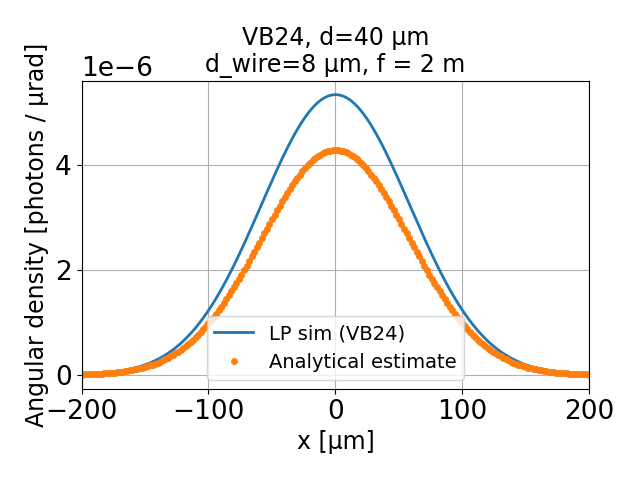

Difference = 19.724394258971532%
Total photons from LP curve = 0.0003883133872687249


In [37]:
# ------- COMPARING VB SIGNAL FROM SIMULATION AND FELIX DATA ---------
import re, ast, pathlib
import numpy as np
import matplotlib.pyplot as plt

# ===================== user parameters =====================
# File naming convention exactly like: d=<d_um>um_f=<f_m>m_dwire=<dwire_um>um
base_dir  = "/home/yu79deg/darkfield_p5438/src/darkfield/VB_analytical_comparison"    # change if needed
d_um      = 40              # Beam diameter [um]
f_m       = 2                # focal length [m]
dwire_um  = 8              # Wire diameter [um]
L_m       = f_m              # Distance at which the Detector is placed from TCC. [m] In General it is not equal to f_m

dataset   = "VB24"          # only used in the plot label
y_scale   = 1e-6           # convert photons/rad -> photons/µrad (Felix data)
x_factor  = f_m            # x = f * θ  (keep identical to your original)
# ===========================================================

def parse_xy_text(tbl_str: str) -> np.ndarray:
    """
    Parse ASCII text with pairs like [x, y] and scientific notation that may use *10^(-N).
    Returns array of shape (N, 2) as float.
    """
    # normalize "*10^(-N)" -> "e-N" so Python can parse it
    s = re.sub(r"\*10\^\(\s*([+-]?\d+)\s*\)", r"e\1", tbl_str)
    # try strict literal parse first
    try:
        data = ast.literal_eval(s)
        arr = np.array(data, dtype=float)
        if arr.ndim == 2 and arr.shape[1] == 2:
            return arr
    except Exception:
        pass

    # fallback: scan numeric tokens and pair them
    num_pat = re.compile(r"[+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?")
    nums = [float(m.group(0)) for m in num_pat.finditer(s)]
    if len(nums) % 2 != 0 or len(nums) < 2:
        raise ValueError("Could not parse any (x,y) pairs from text.")
    return np.asarray(nums, dtype=float).reshape(-1, 2)

def load_felix_xy(base_dir: str, d_um: int, f_m: float, dwire_um: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Build the filename: d=<d_um>um_f=<f_m>m_dwire=<dwire_um>um
    Read it and return x_raw, y_raw as float arrays.
    """
    fname = f"d={d_um}um_f={f_m}m_dwire={dwire_um}um"
    path = pathlib.Path(base_dir) / fname
    text = path.read_text()
    raw_xy = parse_xy_text(text)
    return raw_xy[:, 0], raw_xy[:, 1]

# ---- Load Felix data from file ----
x_raw, y_raw = load_felix_xy(base_dir, d_um, f_m, dwire_um)

# ---- Apply same conversions you used before ----
x_phys = x_raw * x_factor     # x = f * theta
y_phys = y_raw * y_scale      # photons/µrad if input was photons/rad
f = f_m                       # keep your variable name used later

# ------------------------------------------------------------------------------

# ================= LIGHTPIPE SIMULATION : Vertical semi-integration → photons/m → photons/µrad ==============

y_min_um, y_max_um = -L_m * d_um / (2*f_m), L_m * d_um / (2*f_m)       # vertical window (µm) for integration

# Build y-axis (μm) consistent with extent/origin='lower'
Ny = img_scaled.shape[0]
y_vals_um = np.linspace(extent[2], extent[3], Ny)   # from ymin to ymax

# Select rows within [y_min_um, y_max_um]
ymin, ymax = sorted((y_min_um, y_max_um))
mask_rows = (y_vals_um >= ymin) & (y_vals_um <= ymax)
rows = np.where(mask_rows)[0]

# Pixel size along y (m); pixels are square so dy = pixel_size_m
dy_m = pixel_size_m

# Integrate vertically over the selected rows
# img_scaled has units [photons/m^2]; multiplying by dy_m -> [photons/m]
horiz_photons_per_m = np.nansum(img_scaled[rows, :], axis=0) * dy_m

# --- Convert to angular density (photons/µrad), using x = f * θ ---
# dN/dθ = f * dN/dx ; for µrad, multiply by 1e-6
horiz_photons_per_urad = horiz_photons_per_m * f * 1e-6

# Report actual integrated band and basic numbers
y_band_um = (y_vals_um[rows[0]], y_vals_um[rows[-1]])
print(f"Integrated vertically over y ∈ [{y_band_um[0]:.3f}, {y_band_um[1]:.3f}] μm "
      f"({rows.size} rows, dy = {dy_m*1e6:.3f} μm).")

# Your normalization factor
horiz_photons_per_urad = horiz_photons_per_urad * 51 / 25.4796

#--------- PLOT photons/µrad ----------
plt.figure()
plt.plot(x_vals_um, horiz_photons_per_urad, lw=2, label=f"LP sim ({dataset})")
plt.plot(x_phys, y_phys, "o", ms=4, label="Analytical estimate")
plt.xlabel("x [µm]")
plt.ylabel("Angular density [photons / µrad]")
plt.xlim(-200, 200) 
plt.title(f"{dataset}, d={d_um} µm\n"
          f"d_wire={dwire_um} µm, f = {f_m} m")
plt.grid(True)
plt.legend(loc="lower center", frameon=True)
plt.tight_layout()
plt.show()

# =====================================================================================
print(f"Difference = {(1-np.nanmax(y_phys)/np.nanmax(horiz_photons_per_urad))*100}%")
print(f"Total photons from LP curve = {np.nansum(horiz_photons_per_urad)*pixel_size_m/f*1e6}")


Integrated vertically over y ∈ [-99.920, 99.920] μm (1998 rows, dy = 0.100 μm).


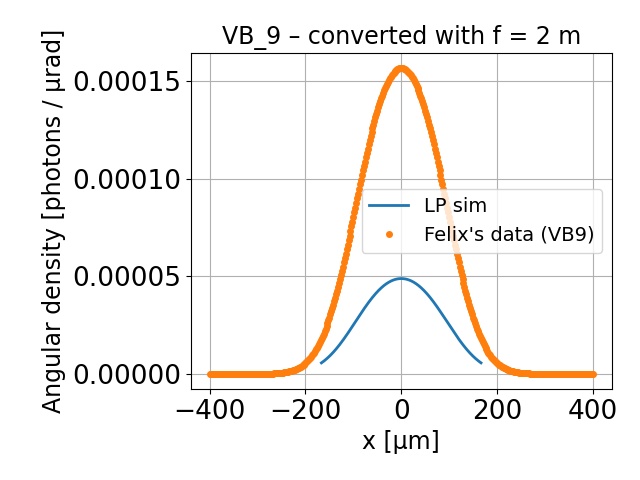

Difference =3.2065451045333497
Total number of photons integrated from curve (LightPipe) = 0.004978833728277408


In [26]:
# ------- COMPARING VB SIGNAL FROM SIMULATION AND FELIX DATA ---------
import re, ast

def parse_table(tbl_str):
    # turn "... *10^(-6)" into scientific notation "...e-6"
    s = re.sub(r'\*10\^\((-?\d+)\)', r'e\1', tbl_str)
    data = ast.literal_eval(s)
    return np.array(data, dtype=float)

# ---- VB8 table ----
vb8_str = """[[-200, 0.02462389747], [-199, 0.02820883599], [-198, 0.03228011370],
[-197, 0.03689834415], [-196, 0.04213094776], [-195, 0.04805277592],
[-194, 0.05474685017], [-193, 0.06230511877], [-192, 0.07082925901],
[-191, 0.08043157131], [-190, 0.09123591412], [-189, 0.1033786784],
[-188, 0.1170098899], [-187, 0.1322942838], [-186, 0.1494125442],
[-185, 0.1685625323], [-184, 0.1899606055], [-183, 0.2138430242],
[-182, 0.2404674210], [-181, 0.2701142851], [-180, 0.3030885888],
[-179, 0.3397213750], [-178, 0.3803715199], [-177, 0.4254274596],
[-176, 0.4753089797], [-175, 0.5304690874], [-174, 0.5913958757],
[-173, 0.6586144018], [-172, 0.7326886887], [-171, 0.8142235844],
[-170, 0.9038667495], [-169, 1.002310503], [-168, 1.110293804],
[-167, 1.228604012], [-166, 1.358078719], [-165, 1.499607494],
[-164, 1.654133376], [-163, 1.822654520], [-162, 2.006225441],
[-161, 2.205958416], [-160, 2.423024229], [-159, 2.658653331],
[-158, 2.914136097], [-157, 3.190823612], [-156, 3.490127327],
[-155, 3.813519137], [-154, 4.162530768], [-153, 4.538752758],
[-152, 4.943833437], [-151, 5.379477067], [-150, 5.847441869],
[-149, 6.349537360], [-148, 6.887621495], [-147, 7.463597095],
[-146, 8.079408027], [-145, 8.737034327], [-144, 9.438487547],
[-143, 10.18580495], [-142, 10.98104348], [-141, 11.82627299],
[-140, 12.72356891], [-139, 13.67500474], [-138, 14.68264329],
[-137, 15.74852828], [-136, 16.87467447], [-135, 18.06305787],
[-134, 19.31560589], [-133, 20.63418560], [-132, 22.02059330],
[-131, 23.47654247], [-130, 25.00365226], [-129, 26.60343469],
[-128, 28.27728309], [-127, 30.02645895], [-126, 31.85207926],
[-125, 33.75510448], [-124, 35.73632504], [-123, 37.79634989],
[-122, 39.93559335], [-121, 42.15426367], [-120, 44.45235110],
[-119, 46.82961726], [-118, 49.28558425], [-117, 51.81952455],
[-116, 54.43045243], [-115, 57.11711505], [-114, 59.87798522],
[-113, 62.71125474], [-112, 65.61482979], [-111, 68.58632577],
[-110, 71.62306457], [-109, 74.72207326], [-108, 77.88008352],
[-107, 81.09353267], [-106, 84.35856622], [-105, 87.67104188],
[-104, 91.02653574], [-103, 94.42034874], [-102, 97.84751543],
[-101, 101.3028156], [-100, 104.7807837], [-99, 108.2757254],
[-98, 111.7817300], [-97, 115.2926887], [-96, 118.8023116],
[-95, 122.3041479], [-94, 125.7916056], [-93, 129.2579742],
[-92, 132.6964478], [-91, 136.1001488], [-90, 139.4621533],
[-89, 142.7755165], [-88, 146.0333006], [-87, 149.2285993],
[-86, 152.3545685], [-85, 155.4044515], [-84, 158.3716089],
[-83, 161.2495451], [-82, 164.0319346], [-81, 166.7126544],
[-80, 169.2858034], [-79, 171.7457350], [-78, 174.0870779],
[-77, 176.3047625], [-76, 178.3940434], [-75, 180.3505199],
[-74, 182.1701583], [-73, 183.8493093], [-72, 185.3847249],
[-71, 186.7735748], [-70, 188.0134573], [-69, 189.1024128],
[-68, 190.0389329], [-67, 190.8219653], [-66, 191.4509222],
[-65, 191.9256792], [-64, 192.2465784], [-63, 192.4144253],
[-62, 192.4304864], [-61, 192.2964793], [-60, 192.0145689],
[-59, 191.5873538], [-58, 191.0178551], [-57, 190.3095005],
[-56, 189.4661095], [-55, 188.4918744], [-54, 187.3913407],
[-53, 186.1693861], [-52, 184.8311969], [-51, 183.3822456],
[-50, 181.8282645], [-49, 180.1752226], [-48, 178.4292951],
[-47, 176.5968388], [-46, 174.6843662], [-45, 172.6985153],
[-44, 170.6460229], [-43, 168.5336977], [-42, 166.3683929],
[-41, 164.1569797], [-40, 161.9063213], [-39, 159.6232485],
[-38, 157.3145355], [-37, 154.9868749], [-36, 152.6468594],
[-35, 150.3009589], [-34, 147.9555024], [-33, 145.6166606],
[-32, 143.2904292], [-31, 140.9826159], [-30, 138.6988269],
[-29, 136.4444565], [-28, 134.2246780], [-27, 132.0444363],
[-26, 129.9084420], [-25, 127.8211675], [-24, 125.7868445],
[-23, 123.8094639], [-22, 121.8927757], [-21, 120.0402909],
[-20, 118.2552852], [-19, 116.5408039], [-18, 114.8996662],
[-17, 113.3344734], [-16, 111.8476155], [-15, 110.4412784],
[-14, 109.1174541], [-13, 107.8779480], [-12, 106.7243895],
[-11, 105.6582404], [-10, 104.6808044], [-9, 103.7932367],
[-8, 102.9965517], [-7, 102.2916329], [-6, 101.6792391],
[-5, 101.1600126], [-4, 100.7344863], [-3, 100.4030870],
[-2, 100.1661428], [-1, 100.0238844], [0, 99.97644972],
[1, 100.0238843], [2, 100.1661427], [3, 100.4030872],
[4, 100.7344864], [5, 101.1600128], [6, 101.6792389],
[7, 102.2916329], [8, 102.9965518], [9, 103.7932365],
[10, 104.6808044], [11, 105.6582403], [12, 106.7243893],
[13, 107.8779480], [14, 109.1174540], [15, 110.4412785],
[16, 111.8476156], [17, 113.3344734], [18, 114.8996661],
[19, 116.5408037], [20, 118.2552851], [21, 120.0402909],
[22, 121.8927757], [23, 123.8094641], [24, 125.7868442],
[25, 127.8211673], [26, 129.9084418], [27, 132.0444363],
[28, 134.2246780], [29, 136.4444565], [30, 138.6988269],
[31, 140.9826159], [32, 143.2904292], [33, 145.6166606],
[34, 147.9555024], [35, 150.3009589], [36, 152.6468594],
[37, 154.9868749], [38, 157.3145355], [39, 159.6232488],
[40, 161.9063213], [41, 164.1569797], [42, 166.3683929],
[43, 168.5336977], [44, 170.6460231], [45, 172.6985153],
[46, 174.6843665], [47, 176.5968388], [48, 178.4292948],
[49, 180.1752226], [50, 181.8282649], [51, 183.3822456],
[52, 184.8311969], [53, 186.1693858], [54, 187.3913407],
[55, 188.4918744], [56, 189.4661092], [57, 190.3095002],
[58, 191.0178548], [59, 191.5873538], [60, 192.0145689],
[61, 192.2964793], [62, 192.4304861], [63, 192.4144256],
[64, 192.2465784], [65, 191.9256792], [66, 191.4509222],
[67, 190.8219656], [68, 190.0389327], [69, 189.1024128],
[70, 188.0134573], [71, 186.7735748], [72, 185.3847253],
[73, 183.8493093], [74, 182.1701583], [75, 180.3505199],
[76, 178.3940434], [77, 176.3047625], [78, 174.0870779],
[79, 171.7457350], [80, 169.2858038], [81, 166.7126544],
[82, 164.0319349], [83, 161.2495447], [84, 158.3716092],
[85, 155.4044515], [86, 152.3545685], [87, 149.2285993],
[88, 146.0333003], [89, 142.7755167], [90, 139.4621533],
[91, 136.1001490], [92, 132.6964478], [93, 129.2579745],
[94, 125.7916056], [95, 122.3041479], [96, 118.8023117],
[97, 115.2926887], [98, 111.7817300], [99, 108.2757253],
[100, 104.7807837], [101, 101.3028154], [102, 97.84751554],
[103, 94.42034863], [104, 91.02653574], [105, 87.67104195],
[106, 84.35856615], [107, 81.09353267], [108, 77.88008356],
[109, 74.72207329], [110, 71.62306457], [111, 68.58632570],
[112, 65.61482982], [113, 62.71125474], [114, 59.87798515],
[115, 57.11711505], [116, 54.43045247], [117, 51.81952458],
[118, 49.28558425], [119, 46.82961726], [120, 44.45235107],
[121, 42.15426360], [122, 39.93559335], [123, 37.79634989],
[124, 35.73632508], [125, 33.75510444], [126, 31.85207930],
[127, 30.02645891], [128, 28.27728314], [129, 26.60343472],
[130, 25.00365222], [131, 23.47654252], [132, 22.02059332],
[133, 20.63418563], [134, 19.31560591], [135, 18.06305792],
[136, 16.87467442], [137, 15.74852826], [138, 14.68264328],
[139, 13.67500469], [140, 12.72356889], [141, 11.82627297],
[142, 10.98104350], [143, 10.18580498], [144, 9.438487550],
[145, 8.737034327], [146, 8.079408020], [147, 7.463597128],
[148, 6.887621485], [149, 6.349537350], [150, 5.847441869],
[151, 5.379477088], [152, 4.943833448], [153, 4.538752762],
[154, 4.162530750], [155, 3.813519144], [156, 3.490127335],
[157, 3.190823615], [158, 2.914136115], [159, 2.658653327],
[160, 2.423024246], [161, 2.205958419], [162, 2.006225457],
[163, 1.822654505], [164, 1.654133373], [165, 1.499607491],
[166, 1.358078730], [167, 1.228604009], [168, 1.110293808],
[169, 1.002310510], [170, 0.9038667495], [171, 0.8142235884],
[172, 0.7326886944], [173, 0.6586144018], [174, 0.5913958688],
[175, 0.5304690892], [176, 0.4753089843], [177, 0.4254274611],
[178, 0.3803715213], [179, 0.3397213736], [180, 0.3030885877],
[181, 0.2701142910], [182, 0.2404674233], [183, 0.2138430262],
[184, 0.1899606016], [185, 0.1685625306], [186, 0.1494125476],
[187, 0.1322942871], [188, 0.1170098891], [189, 0.1033786791],
[190, 0.09123591142], [191, 0.08043157005], [192, 0.07082925664],
[193, 0.06230511654], [194, 0.05474685017], [195, 0.04805277444],
[196, 0.04213094592], [197, 0.03689834588], [198, 0.03228011210],
[199, 0.02820883561], [200, 0.02462389782]]"""

# ---- VB9 table ----
vb9_str = """[[-200, 8.145824792*10^(-6)], [-199, 9.862150884*10^(-6)], [-198, 0.00001192640501],
[-197, 0.00001440590218], [-196, 0.00001738071072], [-195, 0.00002094552728],
[-194, 0.00002521239269], [-193, 0.00003031318199], [-192, 0.00003640360810],
[-191, 0.00004366737119], [-190, 0.00005231971756], [-189, 0.00006261395241],
[-188, 0.00007484695831], [-187, 0.00008936645773], [-186, 0.0001065791600],
[-185, 0.0001269603555], [-184, 0.0001510646808], [-183, 0.0001795371822],
[-182, 0.0002131303612], [-181, 0.0002527166023], [-180, 0.0002993102178],
[-179, 0.0003540850239], [-178, 0.0004184007688], [-177, 0.0004938287392],
[-176, 0.0005821825941], [-175, 0.0006855548256], [-174, 0.0008063508461],
[-173, 0.0009473403261], [-172, 0.001111700477], [-171, 0.001303075417],
[-170, 0.001525638343], [-169, 0.001784161432], [-168, 0.002084094201],
[-167, 0.002431650455], [-166, 0.002833910110], [-165, 0.003298923442],
[-164, 0.003835834261], [-163, 0.004455011810], [-162, 0.005168205877],
[-161, 0.005988703751], [-160, 0.006931511264], [-159, 0.008013561460],
[-158, 0.009253923938], [-157, 0.01067404672], [-156, 0.01229802559],
[-155, 0.01415288936], [-154, 0.01626891146], [-153, 0.01867994843],
[-152, 0.02142382105], [-151, 0.02454271639], [-150, 0.02808360818],
[-149, 0.03209874962], [-148, 0.03664615857], [-147, 0.04179018644],
[-146, 0.04760207270], [-145, 0.05416060046], [-144, 0.06155275107],
[-143, 0.06987439660], [-142, 0.07923109727], [-141, 0.08973885867],
[-140, 0.1015250120], [-139, 0.1147290787], [-138, 0.1295037355],
[-137, 0.1460157644], [-136, 0.1644471073], [-135, 0.1849959256],
[-134, 0.2078776778], [-133, 0.2333263407], [-132, 0.2615955133],
[-131, 0.2929596691], [-130, 0.3277153831], [-129, 0.3661826123],
[-128, 0.4087059539], [-127, 0.4556559101], [-126, 0.5074302601],
[-125, 0.5644552098], [-124, 0.6271867975], [-123, 0.6961120281],
[-122, 0.7717501387], [-121, 0.8546537330], [-120, 0.9454098771],
[-119, 1.044641137], [-118, 1.153006526], [-117, 1.271202297],
[-116, 1.399962729], [-115, 1.540060684], [-114, 1.692308077],
[-113, 1.857556089], [-112, 2.036695449], [-111, 2.230656140],
[-110, 2.440407201], [-109, 2.666956196], [-108, 2.911348402],
[-107, 3.174665989], [-106, 3.458026355], [-105, 3.762580884],
[-104, 4.089512943], [-103, 4.440035607], [-102, 4.815389372],
[-101, 5.216839162], [-100, 5.645671313], [-99, 6.103190101],
[-98, 6.590713688], [-97, 7.109570352], [-96, 7.661093877],
[-95, 8.246618758], [-94, 8.867475070], [-93, 9.524983225],
[-92, 10.22044849], [-91, 10.95515460], [-90, 11.73035796],
[-89, 12.54728149], [-88, 13.40710770], [-87, 14.31097219],
[-86, 15.25995702], [-85, 16.25508380], [-84, 17.29730650],
[-83, 18.38750495], [-82, 19.52647803], [-81, 20.71493668],
[-80, 21.95349757], [-79, 23.24267665], [-78, 24.58288258],
[-77, 25.97441177], [-76, 27.41744198], [-75, 28.91202782],
[-74, 30.45809565], [-73, 32.05543938], [-72, 33.70371732],
[-71, 35.40244804], [-70, 37.15100875], [-69, 38.94863254],
[-68, 40.79440823], [-67, 42.68727853], [-66, 44.62604057],
[-65, 46.60934751], [-64, 48.63570873], [-63, 50.70349294],
[-62, 52.81093115], [-61, 54.95612002], [-60, 57.13702632],
[-59, 59.35149235], [-58, 61.59724131], [-57, 63.87188393],
[-56, 66.17292498], [-55, 68.49777147], [-54, 70.84373979],
[-53, 73.20806536], [-52, 75.58791034], [-51, 77.98037335],
[-50, 80.38249845], [-49, 82.79128632], [-48, 85.20370235],
[-47, 87.61668707], [-46, 90.02716710], [-45, 92.43206380],
[-44, 94.82830332], [-43, 97.21282723], [-42, 99.58260049],
[-41, 101.9346214], [-40, 104.2659303], [-39, 106.5736168],
[-38, 108.8548299], [-37, 111.1067826], [-36, 113.3267602],
[-35, 115.5121274], [-34, 117.6603314], [-33, 119.7689087],
[-32, 121.8354895], [-31, 123.8577999], [-30, 125.8336665],
[-29, 127.7610176], [-28, 129.6378854], [-27, 131.4624065],
[-26, 133.2328227], [-25, 134.9474805], [-24, 136.6048308],
[-23, 138.2034265], [-22, 139.7419215], [-21, 141.2190678],
[-20, 142.6337131], [-19, 143.9847972], [-18, 145.2713491],
[-17, 146.4924823], [-16, 147.6473918], [-15, 148.7353488],
[-14, 149.7556982], [-13, 150.7078516], [-12, 151.5912858],
[-11, 152.4055353], [-10, 153.1501913], [-9, 153.8248957],
[-8, 154.4293373], [-7, 154.9632480], [-6, 155.4264011],
[-5, 155.8186049], [-4, 156.1397040], [-3, 156.3895725],
[-2, 156.5681170], [-1, 156.6752699], [0, 156.7109916],
[1, 156.6752699], [2, 156.5681168], [3, 156.3895726],
[4, 156.1397037], [5, 155.8186050], [6, 155.4264010],
[7, 154.9632482], [8, 154.4293373], [9, 153.8248955],
[10, 153.1501912], [11, 152.4055353], [12, 151.5912858],
[13, 150.7078516], [14, 149.7556982], [15, 148.7353489],
[16, 147.6473916], [17, 146.4924823], [18, 145.2713489],
[19, 143.9847972], [20, 142.6337131], [21, 141.2190678],
[22, 139.7419214], [23, 138.2034265], [24, 136.6048307],
[25, 134.9474805], [26, 133.2328226], [27, 131.4624064],
[28, 129.6378854], [29, 127.7610177], [30, 125.8336665],
[31, 123.8577999], [32, 121.8354894], [33, 119.7689087],
[34, 117.6603313], [35, 115.5121273], [36, 113.3267604],
[37, 111.1067824], [38, 108.8548298], [39, 106.5736169],
[40, 104.2659302], [41, 101.9346215], [42, 99.58260049],
[43, 97.21282732], [44, 94.82830340], [45, 92.43206367],
[46, 90.02716710], [47, 87.61668717], [48, 85.20370235],
[49, 82.79128639], [50, 80.38249855], [51, 77.98037327],
[52, 75.58791035], [53, 73.20806544], [54, 70.84373983],
[55, 68.49777139], [56, 66.17292493], [57, 63.87188384],
[58, 61.59724134], [59, 59.35149237], [60, 57.13702628],
[61, 54.95611994], [62, 52.81093112], [63, 50.70349294],
[64, 48.63570867], [65, 46.60934751], [66, 44.62604062],
[67, 42.68727848], [68, 40.79440828], [69, 38.94863258],
[70, 37.15100866], [71, 35.40244804], [72, 33.70371730],
[73, 32.05543943], [74, 30.45809562], [75, 28.91202784],
[76, 27.41744203], [77, 25.97441171], [78, 24.58288258],
[79, 23.24267663], [80, 21.95349763], [81, 20.71493671],
[82, 19.52647802], [83, 18.38750495], [84, 17.29730645],
[85, 16.25508376], [86, 15.25995708], [87, 14.31097222],
[88, 13.40710769], [89, 12.54728150], [90, 11.73035801],
[91, 10.95515456], [92, 10.22044849], [93, 9.524983257],
[94, 8.867475031], [95, 8.246618729], [96, 7.661093871],
[97, 7.109570352], [98, 6.590713663], [99, 6.103190082],
[100, 5.645671343], [101, 5.216839166], [102, 4.815389356],
[103, 4.440035601], [104, 4.089512921], [105, 3.762580899],
[106, 3.458026365], [107, 3.174665994], [108, 2.911348421],
[109, 2.666956180], [110, 2.440407188], [111, 2.230656137],
[112, 2.036695456], [113, 1.857556099], [114, 1.692308060],
[115, 1.540060677], [116, 1.399962714], [117, 1.271202285],
[118, 1.153006521], [119, 1.044641142], [120, 0.9454098771],
[121, 0.8546537282], [122, 0.7717501433], [123, 0.6961120302],
[124, 0.6271867957], [125, 0.5644552062], [126, 0.5074302546],
[127, 0.4556559137], [128, 0.4087059476], [129, 0.3661826137],
[130, 0.3277153876], [131, 0.2929596678], [132, 0.2615955159],
[133, 0.2333263444], [134, 0.2078776826], [135, 0.1849959223],
[136, 0.1644471081], [137, 0.1460157654], [138, 0.1295037355],
[139, 0.1147290804], [140, 0.1015250112], [141, 0.08973885867],
[142, 0.07923109584], [143, 0.06987439728], [144, 0.06155274981],
[145, 0.05416060283], [146, 0.04760207381], [147, 0.04179018487],
[148, 0.03664615905], [149, 0.03209874780], [150, 0.02808360732],
[151, 0.02454271479], [152, 0.02142382105], [153, 0.01867994741],
[154, 0.01626891017], [155, 0.01415289057], [156, 0.01229802699],
[157, 0.01067404698], [158, 0.009253923450], [159, 0.008013561916],
[160, 0.006931511897], [161, 0.005988703163], [162, 0.005168206426],
[163, 0.004455012489], [164, 0.003835833947], [165, 0.003298923734],
[166, 0.002833910651], [167, 0.002431650830], [168, 0.002084093969],
[169, 0.001784161540], [170, 0.001525638542], [171, 0.001303075600],
[172, 0.001111700477], [173, 0.0009473403261], [174, 0.0008063510624],
[175, 0.0006855545598], [176, 0.0005821828390], [177, 0.0004938286264],
[178, 0.0004184005611], [179, 0.0003540847849], [180, 0.0002993099981],
[181, 0.0002527166023], [182, 0.0002131302499], [183, 0.0001795372842],
[184, 0.0001510645560], [185, 0.0001269604699], [186, 0.0001065791862],
[187, 0.00008936640973], [188, 0.00007484687046], [189, 0.00006261389215],
[190, 0.00005231966246], [191, 0.00004366732085], [192, 0.00003640366938],
[193, 0.00003031312608], [194, 0.00002521235445], [195, 0.00002094558537],
[196, 0.00001738074249], [197, 0.00001440590218], [198, 0.00001192638747],
[199, 9.862190749*10^(-6)], [200, 8.145810300*10^(-6)]]"""

# Parse to numpy
raw_xy_vb8 = parse_table(vb8_str)
raw_xy_vb9 = parse_table(vb9_str)

# ---- Select which dataset to use ----
dataset = "VB9"   # change to "VB9" as needed

if dataset == "VB8":
    raw_xy = raw_xy_vb8
    f = 1              # Focal length in [m]      
else:
    raw_xy = raw_xy_vb9
    f = 2              # Focal length in [m]      

y_scale = 1e-6   # go the photons/urad instead of photons/rad

x_raw = raw_xy[:, 0]
y_raw = raw_xy[:, 1]

x_phys = x_raw * f
y_phys = y_raw * y_scale
# ------------------------------------------------------------------------------

# ================= LIGHTPIPE SIMULATION : Vertical semi-integration → photons/m → photons/µrad ==============

d = 200            # Beam diameter in [um]
y_min_um, y_max_um = -d/2,d/2     # vertical window (μm) for integration
             # propagation distance screen↔source [m] for angle conversion

# Build y-axis (μm) consistent with extent/origin='lower'
Ny = img_scaled.shape[0]
y_vals_um = np.linspace(extent[2], extent[3], Ny)   # from ymin to ymax

# Select rows within [y_min_um, y_max_um]
ymin, ymax = sorted((y_min_um, y_max_um))
mask_rows = (y_vals_um >= ymin) & (y_vals_um <= ymax)
rows = np.where(mask_rows)[0]

# Pixel size along y (m); pixels are square so dy = pixel_size_m
dy_m = pixel_size_m

# Integrate vertically over the selected rows
# img_scaled has units [photons/m^2]; multiplying by dy_m -> [photons/m]
horiz_photons_per_m = np.nansum(img_scaled[rows, :], axis=0) * dy_m

# --- Convert to angular density (photons/µrad), using x = L * theta ---
# dN/dθ = f* dN/dx ; for µrad, multiply by 1e-6
horiz_photons_per_urad = horiz_photons_per_m * f * 1e-6

# Report actual integrated band and basic numbers
y_band_um = (y_vals_um[rows[0]], y_vals_um[rows[-1]])
print(f"Integrated vertically over y ∈ [{y_band_um[0]:.3f}, {y_band_um[1]:.3f}] μm "
        f"({rows.size} rows, dy = {dy_m*1e6:.3f} μm).")

horiz_photons_per_urad = horiz_photons_per_urad * 51 / 25.4796

#--------- PLOT photons/µrad ----------
plt.figure()
plt.plot(x_vals_um, horiz_photons_per_urad, lw=2,label="LP sim")
plt.plot(x_phys, y_phys, "o", ms=4, label=f"Felix's data ({dataset})")
plt.xlabel("x [µm]")
plt.ylabel("Angular density [photons / µrad]")
plt.title(f"{yaml_tag} – converted with f = {f:g} m")
plt.grid(True)
plt.legend(loc="best", frameon=True)
plt.tight_layout()
plt.show()
# =====================================================================================
print(f"Difference ={np.max(y_phys)/np.max(horiz_photons_per_urad)}")
print(f"Total number of photons integrated from curve (LightPipe) = {np.nansum(horiz_photons_per_urad)*pixel_size_m/f*1e6}")

Integrated vertically over y ∈ [-99.920, 99.920] μm (1998 rows, dy = 0.100 μm).


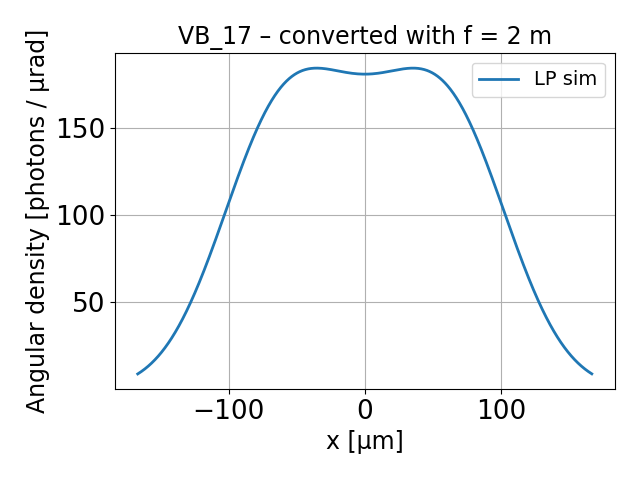

Total number of photons integrated from curve (LightPipe) = 19882.752428563435


In [5]:
# ------- PLOTING THE 1D CURVE OF THE SIGNAL for the LP simulation ---------

# ---- Select which dataset to use in the cell at the beginning of this script ----


# ================= LIGHTPIPE SIMULATION : Vertical semi-integration → photons/m → photons/µrad ==============
f = 2              # Focal length in [m]      
d = 200            # Beam diameter in [um]
y_min_um, y_max_um = -d/2,d/2     # vertical window (μm) for integration


# Build y-axis (μm) consistent with extent/origin='lower'
Ny = img_scaled.shape[0]
y_vals_um = np.linspace(extent[2], extent[3], Ny)   # from ymin to ymax

# Select rows within [y_min_um, y_max_um]
ymin, ymax = sorted((y_min_um, y_max_um))
mask_rows = (y_vals_um >= ymin) & (y_vals_um <= ymax)
rows = np.where(mask_rows)[0]

# Pixel size along y (m); pixels are square so dy = pixel_size_m
dy_m = pixel_size_m

# Integrate vertically over the selected rows
# img_scaled has units [photons/m^2]; multiplying by dy_m -> [photons/m]
horiz_photons_per_m = np.nansum(img_scaled[rows, :], axis=0) * dy_m

# --- Convert to angular density (photons/µrad), using x = L * theta ---
# dN/dθ = f* dN/dx ; for µrad, multiply by 1e-6
horiz_photons_per_urad = horiz_photons_per_m * f * 1e-6

# Report actual integrated band and basic numbers
y_band_um = (y_vals_um[rows[0]], y_vals_um[rows[-1]])
print(f"Integrated vertically over y ∈ [{y_band_um[0]:.3f}, {y_band_um[1]:.3f}] μm "
        f"({rows.size} rows, dy = {dy_m*1e6:.3f} μm).")

#horiz_photons_per_urad = horiz_photons_per_urad * 51 / 25.4796

#--------- PLOT photons/µrad ----------
plt.figure()
plt.plot(x_vals_um, horiz_photons_per_urad, lw=2,label="LP sim")
plt.xlabel("x [µm]")
plt.ylabel("Angular density [photons / µrad]")
plt.title(f"{yaml_tag} – converted with f = {f:g} m")
plt.grid(True)
plt.legend(loc="best", frameon=True)
plt.tight_layout()
plt.show()
# =====================================================================================
print(f"Total number of photons integrated from curve (LightPipe) = {np.nansum(horiz_photons_per_urad)*pixel_size_m/f*1e6}")

Loading figs: /home/yu79deg/darkfield_p5438/Aime/pickles/VB_9_figs.pickle
Loading scaling: /home/yu79deg/darkfield_p5438/Aime/pickles/VB_9_res.pickle
Main plane: TCC_main  |  N=3332, dx=0.100 µm, box=333.3 µm
IR peak intensity (Gaussian): 7.849e+21 W/cm²
Prefactor (choice=ctau_over_lambda): 6.592646e-19
Max S (amplitude) = 1.101e-26


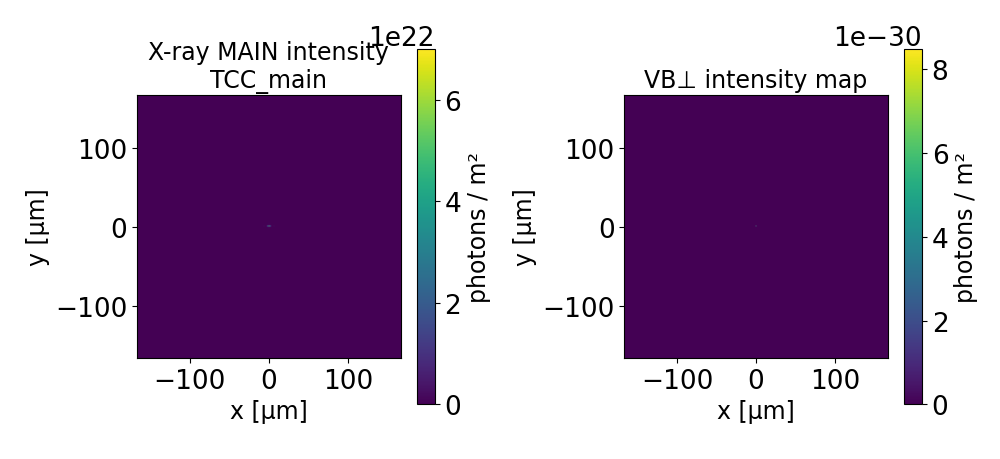

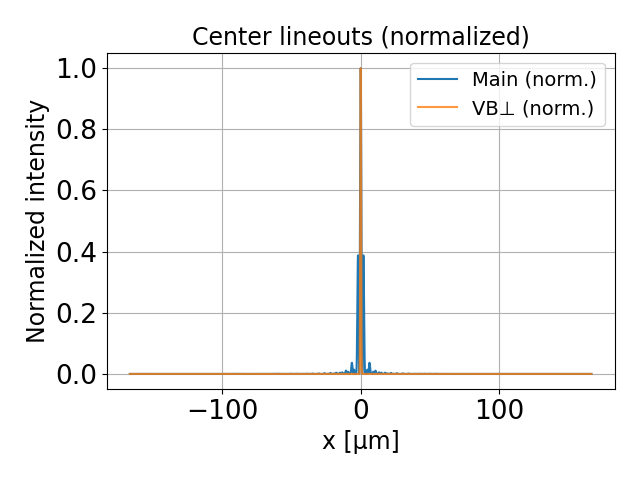

Total MAIN   = 1.995e+11 [photons / m²·m²]
Total VB⊥    = 4.941e-42 [photons / m²·m²]
Done.


In [29]:
# ===================== VB_perp 2D map from X-ray + Gaussian IR =====================
# Standalone script: load X-ray "main" plane from your figs pickle,
# build IR Gaussian intensity, compute VB_perp per the formula, and plot.

import os, pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --------------------- USER PARAMETERS (EDIT) ---------------------
project_dir = '/home/yu79deg/darkfield_p5438/Aime'
yaml_tag    = 'VB_9'

# Which plane (main) to read from figs:
#   e.g. 'flow_075_2.00_main' or 'TCC_main' depending on where you want to apply the mask
#plane_key_main = 'flow_075_2.00_main'
plane_key_main = 'TCC_main'

# Scaling unit for X-ray intensity map (to make VB⊥ in the same unit):
#   'photons' -> uses scale_phot from _res.pickle
#   anything else -> no scaling (a.u.). VB prefactor is unitless so shape/ratios are right anyway.
xray_unit = 'photons'

# --- X-ray wavelength (meters) used in the VB formula ---
wavelength_x = 8766.0 * 1.602176634e-19 / (6.62607015e-34 * 299_792_458.0)  # hc/E, E=8766 eV
# (This equals ≈ 1.415 Å. If you prefer, set explicitly: wavelength_x = 1.415e-10)

# --- IR pulse / geometry (for the Gaussian intensity) ---
tau_FWHM = 30e-15     # s   (your convention is OK; we'll use the same as in your code)
E_pulse  = 4.8        # J
fwhm_diameter = 1.3e-6  # m   IR spot FWHM *diameter* at the interaction plane (your value)
phi_VB = np.pi/4        # radians (45°)
I_cr   = 4.7e29         # W/cm^2  (keep the analytical value you're using)

# Optional offsets of the IR spot center at the plane:
x_offset = 0.0
y_offset = 0.0

# ------- Toggle for prefactor variant (your current choice is 'ctau_over_lambda') ------
prefactor_choice = 'ctau_over_lambda'   # or 'omega_sigma_t' to test the 2π variant
# -------------------------------------------------------------------------------


# --------------------- Helpers (standalone versions) ---------------------
def load_pickle(p):
    with open(p, 'rb') as f:
        return pickle.load(f)

def peak_power(P_peak=None, E=None, tau_FWHM=None):
    if P_peak is not None:
        return float(P_peak)
    if (E is not None) and (tau_FWHM is not None):
        return float(E * np.sqrt(4*np.log(2)/np.pi) / tau_FWHM)
    raise ValueError("Provide P_peak or (E and tau_FWHM).")

def gaussian_spot_map(L, N, fwhm_diameter, P_peak, x_offset=0.0, y_offset=0.0):
    """
    2D circular Gaussian intensity normalized to P_peak:
    I(r) = P_peak * (2/(π w0^2)) * exp(-2 r^2 / w0^2)
    Returns W/cm^2 on an NxN grid spanning L x L centered at 0.
    """
    dx = L / N
    x  = (np.arange(N) - N/2) * dx
    X, Y = np.meshgrid(x, x, indexing='ij')
    # Your convention (kept as-is): FWHM_diameter = sqrt(2 ln2) * w0  =>  w0 = FWHM/√(2 ln2)
    w0 = fwhm_diameter / np.sqrt(2*np.log(2))

    Xs = X - float(x_offset)
    Ys = Y - float(y_offset)
    r  = np.hypot(Xs, Ys)

    G = (2.0 / (np.pi * w0**2)) * np.exp(-2.0 * (r**2) / (w0**2))  # 1/m^2
    I_W_m2 = P_peak * G                                           # W/m^2
    I_W_cm2 = I_W_m2 / 1e4
    return I_W_cm2, x  # return grid axis for extent


# --------------------- Load figs and (optionally) scaling ---------------------
figs_pkl = os.path.join(project_dir, 'pickles', f'{yaml_tag}_figs.pickle')
res_pkl  = os.path.join(project_dir, 'pickles', f'{yaml_tag}_res.pickle')
print(f"Loading figs: {figs_pkl}")
figs = load_pickle(figs_pkl)

if plane_key_main not in figs:
    raise KeyError(f"'{plane_key_main}' not in figs. Available (truncated): {list(figs.keys())[:15]} ...")

print(f"Loading scaling: {res_pkl}")
res = load_pickle(res_pkl)
params = res[1] if isinstance(res, (list, tuple)) and len(res) > 1 else {}

scale_ph  = params.get('scale_phot', 1.0)
scale_Wcm2= params.get('scale_Wcm2', 1.0)

# --------------------- Extract main-plane intensity map & geometry ------------
img_main_raw, ei, prop_size_m, zpos = figs[plane_key_main]
img_main_raw = np.asarray(img_main_raw, dtype=float)
N = img_main_raw.shape[0]
L = float(prop_size_m)
dx = L / N
extent_um = (-L/2*1e6, L/2*1e6, -L/2*1e6, L/2*1e6)

# Scale to chosen unit for display/integration; the VB factor is unitless so this is mainly for consistent units.
if xray_unit == 'photons':
    img_main = img_main_raw * scale_ph     # photons/m^2
    unit_label = 'photons / m²'
else:
    img_main = img_main_raw                # a.u.
    unit_label = 'a.u.'

print(f"Main plane: {plane_key_main}  |  N={N}, dx={dx*1e6:.3f} µm, box={L*1e6:.1f} µm")

# --------------------- Build IR Gaussian intensity (W/cm^2) -------------------
P0 = peak_power(E=E_pulse, tau_FWHM=tau_FWHM)    # W
I_IR_Wcm2, x_axis = gaussian_spot_map(L, N, fwhm_diameter, P0, x_offset=x_offset, y_offset=y_offset)
print(f"IR peak intensity (Gaussian): {I_IR_Wcm2.max():.3e} W/cm²")

# --------------------- VB⊥ amplitude prefactor S(x,y) -------------------------
# Physical constants (SI)
c       = 299_792_458.0
epsilon0= 8.8541878128e-12
hbar    = 1.054571817e-34
e       = 1.602176634e-19
alpha   = e**2 / (4*np.pi*epsilon0*hbar*c)   # fine-structure constant

angle_factor = 3.0*np.sin(2.0*phi_VB)       # = 3 at 45°
# Your convention: tau = tau_FWHM / sqrt(2 ln2)
tau = tau_FWHM / np.sqrt(2*np.log(2))
tau = 51e-15

if prefactor_choice == 'ctau_over_lambda':
    prefactor = np.sqrt(np.pi/2.0) * (alpha/90.0) * (c * tau / wavelength_x) * angle_factor
elif prefactor_choice == 'omega_sigma_t':
    # Alternative (ω * σ_t) = (2π c / λ) * σ_t, with σ_t = tau_FWHM/(2√(2 ln2))
    sigma_t = tau_FWHM / (2.0*np.sqrt(2.0*np.log(2.0)))
    prefactor = np.sqrt(np.pi/2.0) * (alpha/90.0) * ((2.0*np.pi*c/wavelength_x) * sigma_t) * angle_factor
else:
    raise ValueError("prefactor_choice must be 'ctau_over_lambda' or 'omega_sigma_t'")

S_map = prefactor * (I_IR_Wcm2 / I_cr)      # dimensionless amplitude factor

print(f"Prefactor (choice={prefactor_choice}): {prefactor:.6e}")
print(f"Max S (amplitude) = {S_map.max():.3e}")

# --------------------- VB⊥ intensity map: I_perp = S^2 * I_X ------------------
I_vb_perp = (S_map**2) * img_main   # same unit as img_main (e.g. photons/m^2)

# --------------------- PLOTS --------------------------------------------------
plt.figure(figsize=(10,4.6))
plt.subplot(1,2,1)
plt.imshow(img_main, extent=extent_um, origin='lower', aspect='equal')
plt.title(f'X-ray MAIN intensity\n{plane_key_main}')
plt.xlabel('x [µm]'); plt.ylabel('y [µm]')
cb = plt.colorbar(); cb.set_label(unit_label)

plt.subplot(1,2,2)
plt.imshow(I_vb_perp, extent=extent_um, origin='lower', aspect='equal')
plt.title('VB⊥ intensity map')
plt.xlabel('x [µm]'); plt.ylabel('y [µm]')
cb2 = plt.colorbar(); cb2.set_label(unit_label)

plt.tight_layout()
plt.show()

# Central horizontal cut for quick shape check
x_vals_um = np.linspace(extent_um[0], extent_um[1], N)
j = N//2
plt.figure()
plt.plot(x_vals_um, img_main[j,:] / np.max(img_main[j,:]), label='Main (norm.)')
plt.plot(x_vals_um, I_vb_perp[j,:] / np.max(I_vb_perp[j,:]), label='VB⊥ (norm.)', alpha=0.8)
plt.xlabel('x [µm]'); plt.ylabel('Normalized intensity')
plt.title('Center lineouts (normalized)')
plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

# Integrals (optional, in chosen unit × m²)
pixel_area = dx*dx
sum_main   = np.nansum(img_main)   * pixel_area
sum_vbperp = np.nansum(I_vb_perp)  * pixel_area
print(f"Total MAIN   = {sum_main:.3e} [{unit_label}·m²]")
print(f"Total VB⊥    = {sum_vbperp:.3e} [{unit_label}·m²]")
print("Done.")
# ============================================================================== 


lambda_x = 1.414376e-10 m  (0.141 nm)
Energy in Joules = 0.00039325105046203197 J
I0 = 3.619629e+21


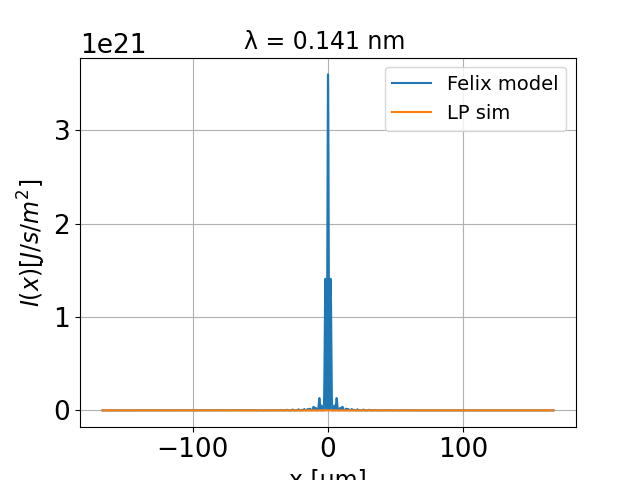

In [70]:
# ------- COMPARING THE XRAY AT TCC FROM FELIX AND SIMULATION -----

import numpy as np
import matplotlib.pyplot as plt

# --- Physical constants (SI) ---
h   = 6.62607015e-34           # Planck [J·s]
hbar= 1.054571817e-34          # reduced Planck [J·s]
c   = 299_792_458.0            # speed of light [m/s]
eV  = 1.602176634e-19          # 1 eV in Joules [J]

# --- Photon energy & derived quantities ---
E_eV = 8766.0                  # given
E_J  = E_eV * eV               # energy in Joules
lambda_x = (h * c) / E_J       # wavelength [m]

# --- Beam Parameters ----------- 
Beam_diam = 200e-6 # beam diameter just before the CRL4a [m] 
focal_length = 2 # Distance between CRL4a and TCC (for a collimated beam = f_crl4a) [m] 
d_wire = 60e-6 # Wire diameter [m]

print(f"lambda_x = {lambda_x:.6e} m  ({lambda_x*1e9:.3f} nm)")

# --- Example: your W_x depends on what you mean physically --------------------
N_x = 2e11
N_x = 2.8e11
W_J = N_x * E_J                # or: W_J = N_x * hbar * omega_x. Energy of the full beam in [Joules]

# ----- Definitions of times --------
tau_FWHM = 25e-15                               # The real (experimentaly measured), pulse duration (25 fs) [s]
tau_RMS = tau_FWHM / (2*np.sqrt(2*np.log(2)))   # tau_rms [s]
tau_Felix = 4 * tau_RMS                         # Typical time defined by Felix with the different convention for the gaussian integral [s]

print(f"Energy in Joules = {W_J} J")
# --- I_x(0) from the formula ---------------------------------------------------
I0 =  2.0 * np.sqrt(2.0/np.pi) * (W_J / (tau_Felix * lambda_x**2)) * (Beam_diam/focal_length)**2 * (1.0 - d_wire/Beam_diam)**2
print(f"I0 = {I0:.6e}")
# --- Function for I_x(x)/I_x(0) -----------------------------------------------

def Ix_norm(x, lam, d, d_wire, f):
    """
    I_x(x) / I_x(0) = 1 / (1 - d_wire/d)^2 * [ (sin(π x/lam * d/f) - sin(π x/lam * d_wire/f))
                                               / (π x/lam * d/f) ]^2
    Handles the removable singularity at x=0 by taking the analytic limit.
    """
    Ad  = np.pi * x/lam * d/f
    Adw = np.pi * x/lam * d_wire/f
    num = np.sin(Ad) - np.sin(Adw)
    den = Ad
    # limit x->0 of (num/den) is (1 - d_wire/d)
    core = np.where(np.isclose(x, 0.0), 1.0 - d_wire/d, num/den)
    return (1.0 / (1.0 - d_wire/d)**2) * core**2

# --- Compute & plot ------------------------------------------------------------
I_felix = I0 * Ix_norm(x_vals_um*1e-6, lambda_x, Beam_diam, d_wire, focal_length)

# ------ Scale my result to an intensity unit ----------

Typical_time = np.sqrt(2*np.pi) * tau_RMS       # Le facteur devant le "typical time" doit correspondre au facteur issu de l'integrale.
I_lightPipe = horizontal * E_J / Typical_time

fig, ax = plt.subplots()
ax.plot(x_vals_um, I_felix, label="Felix model")  # Felix's estimation
ax.plot(x_vals_um, I_lightPipe,label="LP sim")  # LightPipe Simulation
ax.set_xlabel("x [um]")
ax.set_ylabel(r"$I(x) [J/s/m^2]$")
ax.set_title(f"λ = {lambda_x*1e9:.3f} nm ")
ax.grid(True)
ax.legend(loc="best", frameon=True)   # show legend
plt.show()


lambda_x = 1.414376e-10 m  (0.141 nm)
omega_x  = 1.331790e+19 rad/s


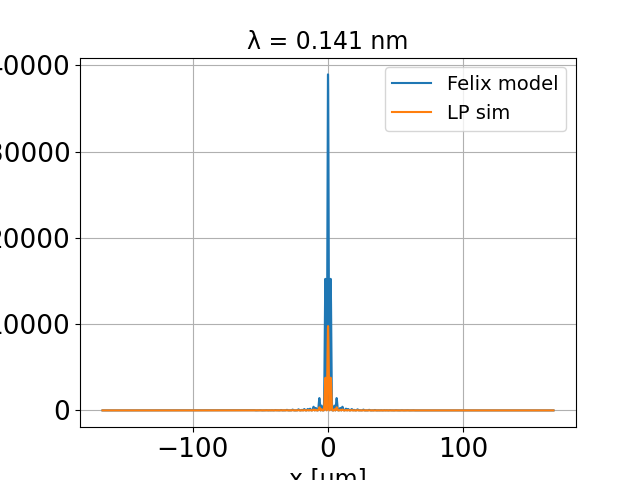

In [ ]:
# ------- COMPARING THE NORMALISED QUANTITY FROM FELIX AND SIMULATION -----

import numpy as np
import matplotlib.pyplot as plt

# --- Physical constants (SI) ---
h   = 6.62607015e-34           # Planck [J·s]
hbar= 1.054571817e-34          # reduced Planck [J·s]
c   = 299_792_458.0            # speed of light [m/s]
eV  = 1.602176634e-19          # 1 eV in Joules [J]

# --- Photon energy & derived quantities ---
E_eV = 8766.0                  # given
E_J  = E_eV * eV               # energy in Joules
lambda_x = (h * c) / E_J       # wavelength [m]
omega_x  = 2*np.pi * c / lambda_x   # angular frequency [rad/s]

# --- Beam Parameters ----------- 
Beam_diam = 200e-6 # beam diameter just before the CRL4a [m] 
focal_length = 2 # Distance between CRL4a and TCC (for a collimated beam = f_crl4a) [m] 
d_wire = 60e-6 # Wire diameter [m]

print(f"lambda_x = {lambda_x:.6e} m  ({lambda_x*1e9:.3f} nm)")
print(f"omega_x  = {omega_x:.6e} rad/s")

# --- NEW analytical curve from Felix -------------------
def Ix_over_Iin(x, lam, d, d_wire, f, dx, dy):
    """
    Returns I_x(x) / I_{x,input} per:
        4*dx*dy/lam^2 * [ (sin(pi*x/lam*d/f) - sin(pi*x/lam*d_wire/f)) / (pi*x/lam) ]^2
    Handles the removable singularity at x=0 with the analytic limit:
        -> ((d - d_wire)/f)^2
    """
    A   = np.pi * x / lam                        # dimensionless
    num = np.sin(A * d / f) - np.sin(A * d_wire / f)
    den = A

    # analytic limit at x=0: (num/den) -> (d - d_wire)/f
    core = np.where(np.isclose(x, 0.0), (d - d_wire) / f, num / den)

    return (4.0 * dx * dy / lam**2) * core**2


# ---- build and plot the analytical curve (keep the rest of your code the same) -
I_model = Ix_over_Iin(
    x_vals_um * 1e-6,    # x in meters
    lambda_x,            # lam
    Beam_diam,           # d
    d_wire,              # d_wire
    focal_length,        # f
    Beam_diam,           # dx
    Beam_diam            # dy
)

peak_input_plane = 7.16e18   #  Value of flux at the input plane of my sim : [photons/m^2]


fig, ax = plt.subplots()
ax.plot(x_vals_um, I_model, label="Felix model")
ax.plot(x_vals_um, horizontal / peak_input_plane, label="LP sim")  # your existing normalization
ax.set_xlabel("x [µm]")
ax.set_ylabel(r"$I_x/I_{x,\mathrm{input}}$")
ax.set_title(f"λ = {lambda_x*1e9:.3f} nm")
ax.grid(True)
ax.legend(loc="best", frameon=True)
plt.show()



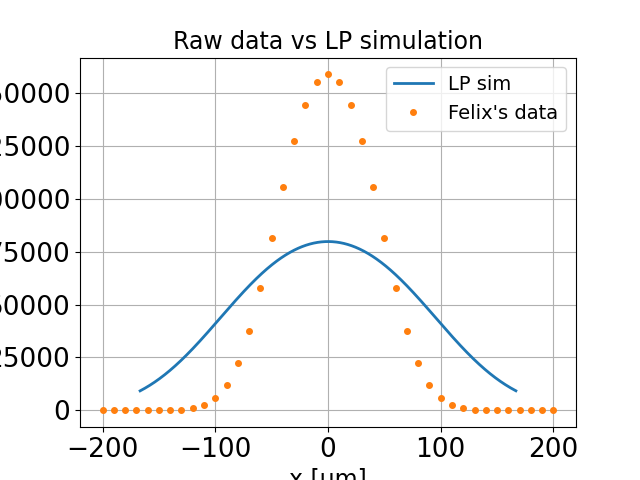

In [71]:
# ------- COMPARING THE VB SIGNAL AT DETECTOR FROM FELIX AND SIMULATION -----
import numpy as np
import matplotlib.pyplot as plt

# --- raw data: x in µm, y in arb. units ---------------------------------------
"""
# Data for VB8
raw_xy = np.array([
    [-200, 2.681998692e-4], [-190, 9.937281566e-4], [-180, 3.301196329e-3],
    [-170, 9.844783684e-3], [-160, 2.639122350e-2], [-150, 6.368947673e-2],
    [-140, 1.385832410e-1], [-130, 2.723361027e-1], [-120, 4.841684698e-1],
    [-110, 7.801078841e-1], [-100, 1.141256884e+0], [-90, 1.519001261e+0],
    [-80,  1.843836071e+0], [-70,  2.047814922e+0], [-60,  2.091394441e+0],
    [-50,  1.980446712e+0], [-40,  1.763459837e+0], [-30,  1.510687221e+0],
    [-20,  1.288019172e+0], [-10,  1.140167925e+0], [0,   1.088928785e+0],
    [10,   1.140167924e+0], [20,  1.288019172e+0], [30,  1.510687221e+0],
    [40,   1.763459837e+0], [50,  1.980446715e+0], [60,  2.091394441e+0],
    [70,   2.047814922e+0], [80,  1.843836075e+0], [90,  1.519001261e+0],
    [100,  1.141256884e+0], [110, 7.801078841e-1], [120, 4.841684693e-1],
    [130,  2.723361022e-1], [140, 1.385832409e-1], [150, 6.368947673e-2],
    [160,  2.639122368e-2], [170, 9.844783684e-3], [180, 3.301196315e-3],
    [190,  9.937281272e-4], [200, 2.681998731e-4],
], dtype=float)
"""
# Data for VB9

raw_xy = np.array([
    [-200, 8.872312544e-8],  [-190, 5.698586677e-7],  [-180, 3.260042867e-6],
    [-170, 1.661702843e-5],  [-160, 7.549700113e-5],  [-150, 3.058825294e-4],
    [-140, 1.105795497e-3],  [-130, 3.569427750e-3],  [-120, 1.029726532e-2],
    [-110, 2.658055627e-2],  [-100, 6.149182151e-2],  [-90,  1.277653335e-1],
    [-80,  2.391142663e-1],  [-70,  4.046433227e-1],  [-60,  6.223280864e-1],
    [-50,  8.755143496e-1],  [-40,  1.135649177e+0],  [-30,  1.370561786e+0],
    [-20,  1.553545423e+0],  [-10,  1.668089357e+0],  [0,    1.706873070e+0],
    [10,   1.668089356e+0],  [20,   1.553545423e+0],  [30,   1.370561787e+0],
    [40,   1.135649175e+0],  [50,   8.755143506e-1],  [60,   6.223280859e-1],
    [70,   4.046433218e-1],  [80,   2.391142670e-1],  [90,   1.277653340e-1],
    [100,  6.149182185e-2],  [110,  2.658055613e-2],  [120,  1.029726532e-2],
    [130,  3.569427797e-3],  [140,  1.105795488e-3],  [150,  3.058825201e-4],
    [160,  7.549700800e-5],  [170,  1.661703058e-5],  [180,  3.260040474e-6],
    [190,  5.698580678e-7],  [200,  8.872296762e-8],
], dtype=float)

x_raw = raw_xy[:, 0] # theta_x in urad
y_raw = raw_xy[:, 1]

# --- plot ----------------------------------------------------------------------
y_phys = 93000 * y_raw #scaling by a random factor. For VB9
#y_phys = 47000 * y_raw #scaling by a random factor. For VB9
x_phys = x_raw * 1 # x [um] For VB8
#x_phys = x_raw * 2 # x [um] For VB9


fig, ax = plt.subplots()
ax.plot(x_vals_um, horizontal, lw=2, label="LP sim")         # existing curve
ax.plot(x_phys, y_phys, "o", ms=4, label="Felix's data")           # raw points
# (optional) connect the points:
# ax.plot(x_raw, y_raw, "C1o-", lw=1, ms=3, label="Raw data")

ax.set_xlabel("x [µm]")
ax.set_ylabel("Intensity (arb. u.)")
ax.set_title("Raw data vs LP simulation")
ax.grid(True)
ax.legend(loc="best", frameon=True)
plt.show()

In [17]:
#################### COMPUTE FWHM #################
N = img_scaled.shape[0]
y_center_index = N // 2

I = img_scaled[y_center_index, :]  # Horizontal cut at center (y=0)
x = (np.arange(len(I)) - len(I)//2) * pixel_size_um  # µm


# Normalize if needed (optional for FWHM)
I = I / np.max(I)   # Normalize to peak = 1

# Compute FWHM
half_max = 0.5
above_half = I >= half_max

# Find the first and last index where intensity is above half max
indices = np.where(above_half)[0]

if len(indices) >= 2:
    x_left = x[indices[0]]
    x_right = x[indices[-1]]
    fwhm = x_right - x_left
    print(f"FWHM = {fwhm:.2f} µm")
else:
    print("Could not determine FWHM (signal too weak or flat)")

FWHM = 641.67 µm


In [20]:
np.sqrt(1.141285e+24 / 7.001703324205907e+22)

np.float64(4.037338862533089)

In [25]:
971.3-962.325

8.974999999999909

In [21]:
tau_FWHM = 30
tau_Felix = tau_FWHM * np.sqrt(2 / np.log(2))
print(tau_Felix)

50.959308017281145


Loading images: /home/yu79deg/darkfield_p5438/Aime/pickles/VB_9_figs.pickle
Loading scaling: /home/yu79deg/darkfield_p5438/Aime/pickles/VB_9_res.pickle
dict_keys(['flow_000_-2.50_main', 'flow_001_-2.44_main', 'flow_002_-2.38_main', 'flow_003_-2.32_main', 'flow_004_-2.26_main', 'flow_005_-2.20_main', 'flow_006_-2.14_main', 'flow_007_-2.08_main', 'flow_008_-2.02_main', 'beam_shaper_main', 'O1_main', 'CRL4a_main', 'flow_009_-1.96_main', 'flow_010_-1.90_main', 'flow_011_-1.84_main', 'flow_012_-1.78_main', 'flow_013_-1.72_main', 'flow_014_-1.66_main', 'flow_015_-1.60_main', 'flow_016_-1.54_main', 'flow_017_-1.48_main', 'flow_018_-1.42_main', 'flow_019_-1.36_main', 'flow_020_-1.30_main', 'flow_021_-1.24_main', 'flow_022_-1.18_main', 'flow_023_-1.12_main', 'flow_024_-1.06_main', 'flow_025_-1.00_main', 'flow_026_-0.94_main', 'flow_027_-0.88_main', 'flow_028_-0.82_main', 'flow_029_-0.76_main', 'flow_030_-0.70_main', 'flow_031_-0.64_main', 'flow_032_-0.58_main', 'flow_033_-0.52_main', 'flow_034_

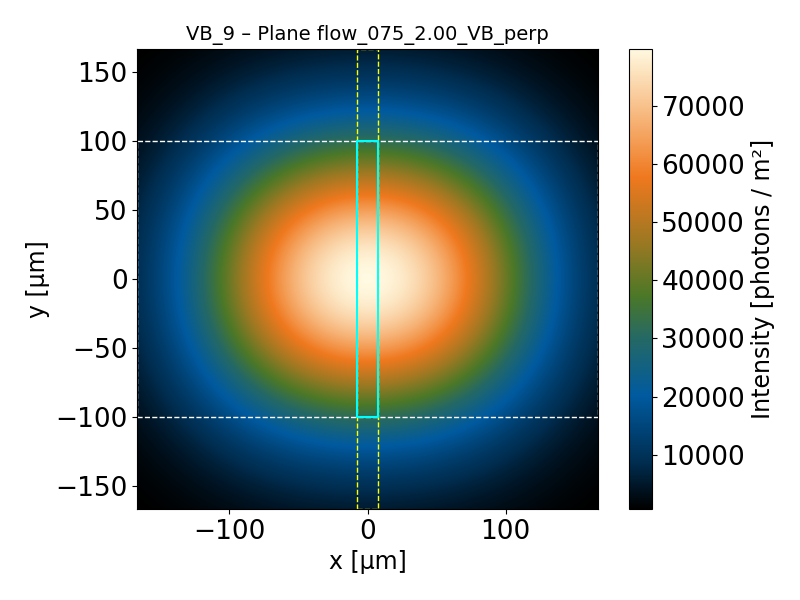

FWHM = 203.542 μm


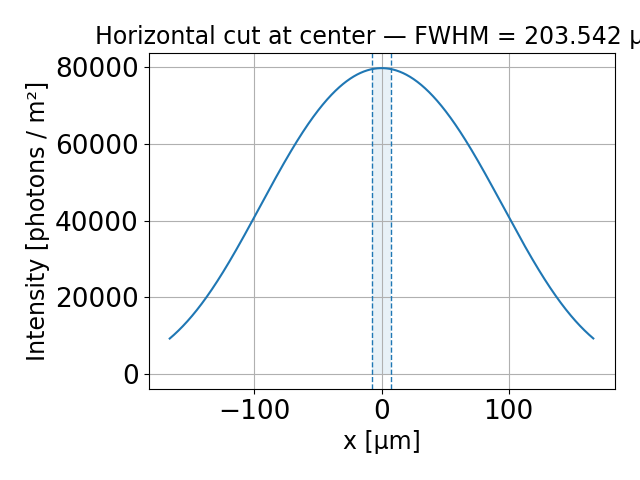

In [5]:
###################### BENCHMARK WITH FELIX ####################
%matplotlib widget
import os, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ----------------- USER PARAMETERS -----------------
project_dir = '/home/yu79deg/darkfield_p5438/Aime'
yaml_tag = 'VB_9'  # Simulation name
# plane_to_visualize examples:
# 'flow_733_9.99', 'start', 'Det_VB_parr', 'beam_shaper_main'
plane_to_visualize = 'flow_075_2.00_VB_perp'

# ----- Choose unit -------
intensity_unit = 'photons'  # 'relative', 'photons', 'Wcm2'

# ----- Display scaling -----
use_log = False        # True → log display, False → linear
log_vmin_mode = "auto" # "auto" or float (e.g. 1e-12) for the lowest log level

# --- Beam Parameters -----------
Beam_diam     = 200e-6   # beam diameter just before CRL4a [m]
focal_length  = 1.0      # distance between CRL4a and TCC [m]
d_wire        = 60e-6    # wire diameter [m]

# --- Integration half-widths from simple geometry ---
theta_x = d_wire    / (2 * focal_length) / 4   # "wire-limited" angle in x [rad]
theta_y = Beam_diam / (2 * focal_length)       # beam convergence in y [rad]

Distance_integration_plane_from_TCC = 1.0      # [m]
x_int_um = Distance_integration_plane_from_TCC * theta_x * 1e6  # [µm]
y_int_um = Distance_integration_plane_from_TCC * theta_y * 1e6  # [µm]

# ----- Construct pickle file paths -----
pickle_file = os.path.join(project_dir, 'pickles', f'{yaml_tag}_figs.pickle')
print(f"Loading images: {pickle_file}")

res_file = os.path.join(project_dir, 'pickles', f'{yaml_tag}_res.pickle')
print(f"Loading scaling: {res_file}")
res = mu.loadPickle(res_file)
params = res[1]

# ----- Select scaling based on chosen unit -----
scale_ph   = params.get('scale_phot', 1.0)
scale_Wcm2 = params.get('scale_Wcm2', 1.0)

if intensity_unit == 'photons':
    scale = scale_ph
    unit_label = 'photons / m²'
elif intensity_unit == 'Wcm2':
    scale = scale_Wcm2
    unit_label = 'W cm⁻²'
else:
    scale = 1.0
    unit_label = 'a.u.'

# ----- Load images dict -----
figs = mu.loadPickle(pickle_file)
print(figs.keys())

# --- Visualize exactly one plane (no loop) ---
if plane_to_visualize not in figs:
    print(f"[error] '{plane_to_visualize}' not found in figs.")
    print("Available keys (truncated):", list(figs.keys())[:20], "…")
else:
    data = figs[plane_to_visualize]      # [image, ei, propsize/ZoomFactor, z]
    img = data[0].astype(float)
    prop_size_m = float(data[2])         # physical box size (meters)
    N = img.shape[0]
    pixel_size_m  = prop_size_m / N
    pixel_size_um = pixel_size_m * 1e6

    print(f"Selected plane: {plane_to_visualize}")
    print(f"N={N}, dx={pixel_size_um:.3f} µm, box={prop_size_m*1e6:.1f} µm")

    # Scale + extent
    img_scaled = img * scale
    extent = (-prop_size_m/2*1e6, prop_size_m/2*1e6,
              -prop_size_m/2*1e6, prop_size_m/2*1e6)  # [xmin, xmax, ymin, ymax] in µm

    # ---- Total photons (or total W·m² if Wcm2) ----
    pixel_area_m2 = (pixel_size_m ** 2)
    sum_map = np.nansum(img_scaled)
    intensity_sum = sum_map * pixel_area_m2
    print(f"Total (map sum × pixel area) = {intensity_sum:.3e} [{unit_label}·m²]")

    # --- coordinate arrays in µm (matching image axes) ---
    x_vals_um = np.linspace(extent[0], extent[1], img_scaled.shape[1])
    y_vals_um = np.linspace(extent[2], extent[3], img_scaled.shape[0])

    # --- boolean masks for the bands (rows/cols) ---
    mask_y_band = (y_vals_um >= -y_int_um) & (y_vals_um <= y_int_um)   # rows (horizontal band)
    mask_x_band = (x_vals_um >= -x_int_um) & (x_vals_um <= x_int_um)   # cols (vertical band)

    # --- band and rectangle integrals (photons) ---
    photons_in_horizontal_band = np.nansum(img_scaled[mask_y_band, :]) * pixel_area_m2
    photons_in_vertical_band   = np.nansum(img_scaled[:, mask_x_band]) * pixel_area_m2
    photons_in_rectangle       = np.nansum(img_scaled[np.ix_(mask_y_band, mask_x_band)]) * pixel_area_m2

    # --- fractions of the total ---
    frac_y  = photons_in_horizontal_band / intensity_sum if intensity_sum > 0 else np.nan
    frac_x  = photons_in_vertical_band   / intensity_sum if intensity_sum > 0 else np.nan
    frac_xy = photons_in_rectangle       / intensity_sum if intensity_sum > 0 else np.nan

    print(f"[horizontal band  y∈[{ -y_int_um:.1f}, { y_int_um:.1f}] µm]  "
          f"photons = {photons_in_horizontal_band:.3e}  ({frac_y:.2%} of total)")
    print(f"[vertical band    x∈[{ -x_int_um:.1f}, { x_int_um:.1f}] µm]  "
          f"photons = {photons_in_vertical_band:.3e}  ({frac_x:.2%} of total)")
    print(f"[rectangle       x∈[{ -x_int_um:.1f}, { x_int_um:.1f}] µm, y∈[{ -y_int_um:.1f}, { y_int_um:.1f}] µm]  "
          f"photons = {photons_in_rectangle:.3e}  ({frac_xy:.2%} of total)")

    # ---- Norm (optional log) ----
    norm = None
    if use_log:
        pos = img_scaled > 0
        if np.any(pos):
            vmax = float(np.nanmax(img_scaled))
            vmin = (float(np.nanpercentile(img_scaled[pos], 0.1))
                    if log_vmin_mode == "auto" else float(log_vmin_mode))
            from matplotlib.colors import LogNorm
            vmin = max(min(vmin, 0.99*vmax), np.finfo(float).tiny)
            norm = LogNorm(vmin=vmin, vmax=vmax)
        else:
            print("[warn] No positive pixels, falling back to linear.")
            use_log = False

    # ---- 2D image ----
    plt.figure(figsize=(8, 6))
    im2d = plt.imshow(img_scaled, cmap=rofl.cmap(), norm=norm,
                      extent=extent, origin='lower', aspect='equal')
    plt.title(f'{yaml_tag} – Plane {plane_to_visualize}', fontsize=14)
    plt.xlabel('x [μm]'); plt.ylabel('y [μm]')
    plt.colorbar(im2d, label=f'Intensity [{unit_label}]')

    # --- overlay the bands + rectangle on the image ---
    ax = plt.gca()
    # Horizontal band (full width in x, height = 2*y_int_um)
    rect_h = patches.Rectangle(
        (extent[0], -y_int_um),
        width = extent[1] - extent[0],
        height = 2*y_int_um,
        linewidth = 1.0, edgecolor='white', facecolor='none', linestyle='--'
    )
    # Vertical band (full height in y, width = 2*x_int_um)
    rect_v = patches.Rectangle(
        (-x_int_um, extent[2]),
        width = 2*x_int_um,
        height = extent[3] - extent[2],
        linewidth = 1.0, edgecolor='yellow', facecolor='none', linestyle='--'
    )
    # Intersection rectangle
    rect_xy = patches.Rectangle(
        (-x_int_um, -y_int_um),
        width = 2*x_int_um,
        height = 2*y_int_um,
        linewidth = 1.5, edgecolor='cyan', facecolor='none', linestyle='-'
    )
    ax.add_patch(rect_h)
    ax.add_patch(rect_v)
    ax.add_patch(rect_xy)

    plt.tight_layout()
    plt.show()

    # ---- Central horizontal cut + FWHM ----
    center_y = img_scaled.shape[0] // 2
    horizontal = img_scaled[center_y, :]

    plt.figure()
    if use_log:
        plt.semilogy(x_vals_um, np.maximum(horizontal, np.finfo(float).tiny))
    else:
        plt.plot(x_vals_um, horizontal)

    # Vertical guides at ±x_int_um on the lineout
    plt.axvline(-x_int_um, linestyle='--', linewidth=1.0)
    plt.axvline(+x_int_um, linestyle='--', linewidth=1.0)
    # Optional shading of the selected x-range
    try:
        ymax_line = np.nanmax(horizontal) if not use_log else np.nanmax(np.maximum(horizontal, np.finfo(float).tiny))
        plt.fill_between(x_vals_um, 0, ymax_line,
                         where=(x_vals_um >= -x_int_um) & (x_vals_um <= x_int_um),
                         alpha=0.1)
    except ValueError:
        pass  # in case of all-NaN

    plt.xlabel('x [μm]'); plt.ylabel(f'Intensity [{unit_label}]')

    # FWHM
    I_line = horizontal
    if np.nanmax(I_line) > 0:
        I_norm = I_line / np.nanmax(I_line)
        above = I_norm >= 0.5
        idx = np.where(above)[0]
        if idx.size >= 2:
            x_left, x_right = x_vals_um[idx[0]], x_vals_um[idx[-1]]
            fwhm = x_right - x_left
            plt.title(f'Horizontal cut at center — FWHM = {fwhm:.3f} μm')
            print(f"FWHM = {fwhm:.3f} μm")
        else:
            plt.title('Horizontal cut at center — FWHM undetermined')
            print("Could not determine FWHM (signal too weak or flat).")
    else:
        plt.title('Horizontal cut at center — all zeros')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np

# --- Physical constants (SI) ---
h   = 6.62607015e-34           # Planck [J·s]
hbar= 1.054571817e-34          # reduced Planck [J·s]
c   = 299_792_458.0            # speed of light [m/s]
eV  = 1.602176634e-19          # 1 eV in Joules [J]

# --- Photon energy & derived quantities ---
E_eV = 8766.0                  # given
E_J  = E_eV * eV               # energy in Joules
lam_x = (h * c) / E_J       # wavelength [m]
print(f"lambda_x ={lam_x*1e9}nm")

d = 200e-6
f=2
lam_x = lam_x

factor = d**4 / ((lam_x**2)*(f**2))

print(f"Factor between input and TCC intensities = {factor}")

Factor_sim = 1e23 / 5e18

print(f"Factor from the LP simulation = {Factor_sim}")

lambda_x =0.14143759803011666nm
Factor between input and TCC intensities = 19995.40691853331
Factor from the LP simulation = 20000.0


In [56]:
import numpy as np

# --- Constants ---
eV = 1.602176634e-19  # J

# --- Inputs ---
E_eV = 8766.0                     # photon energy [eV]
N = 2.0e11                        # photons per pulse
d = 200e-6                        # square side [m]
tau_FWHM = 25e-15                 # intensity FWHM [s]

# --- Derived ---
E_J = E_eV * eV                   # J per photon
sigma_t = tau_FWHM / (2*np.sqrt(2*np.log(2)))  # RMS of intensity [s]
A = d**2                          # area [m^2]
T_peak = 1.0 / (np.sqrt(2*np.pi) * sigma_t)

I_peak = N * E_J / A * T_peak     # W/m^2  (peak in time, uniform in space)


print(f"N EJ = { N * E_J}")
print(f"I_peak = {I_peak:.3e} J/s/m^2")




N EJ = 0.00028089360747287994
I_peak = 2.639e+17 J/s/m^2


In [14]:
5.48 * 51 / 25

11.179200000000002

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from darkfield.diffra_v2 import peak_power


# Calculate the intensity of IR laser :
f_IR = 0.1 # focal lenght of the final parabolla in m
D_IR = 0.1 # diameter of the final parabolla in m
wavelength_IR = 800e-9 # Wavelenght of the IR laser, in m
phi_VB = np.pi / 4 #45 degrees angle between the IR and X beams.

# Define E_pulse (OR) P_peak
tau_FWHM = 30e-15 # Laser FWHM duration in second
E_pulse  = 4.8  # Joules


Peak_power = peak_power(P_peak=None, E=E_pulse, tau_FWHM=tau_FWHM)

FWHM_diam = 1.3e-6    # IR FWHM diameter [m]
w0 = FWHM_diam / np.sqrt(2*np.log(2))

I_Peak_W_cm2 =  Peak_power * 2.0 / (np.pi * w0**2) / 1e4

print(f"Peak intensity = {I_Peak_W_cm2} W/cm^2")
print(f"My tau for formula = {tau_FWHM / np.sqrt(2*np.log(2))*1e15}fs")
print(f"Felix's tau for formula = {tau_FWHM * np.sqrt(2/np.log(2))*1e15}fs")


Peak intensity = 7.84940337199229e+21 W/cm^2
My tau for formula = 25.479654008640573fs
Felix's tau for formula = 50.959308017281145fs


In [15]:
import numpy as np
from numpy.polynomial.hermite import hermgauss
from scipy.special import wofz  # Faddeeva (stable)

# ----- inputs -----
c   = 299_792_458.0
lambda_IR = 800e-9
FWHM_diam = 1.3e-6

# Your convention: FWHM_diam -> 1/e^2 waist radius
w0 = FWHM_diam / np.sqrt(2*np.log(2))        # [m]
zR = np.pi * w0**2 / lambda_IR               # [m]

T_FWHM   = 25e-15                            # probe (FWHM) [s]
tau_FWHM = 30e-15                            # pump  (FWHM) [s]
t0  = 0.0                                    # [s]

# Convert FWHM -> 1/e^2 times (your convention)
T   = T_FWHM   * 2 / np.sqrt(2*np.log(2))    # [s]
tau = tau_FWHM * 2 / np.sqrt(2*np.log(2))    # [s]

# Assemble χ, χ0, ρ (times → lengths via c)
sigma = np.sqrt((c*T)**2 + (c*tau)**2 / 2.0) # [m]
chi   = 4.0 * zR / sigma
chi0  = 2.0 * (c*t0) / sigma
rho   = T / tau

def F_of_stable(chi: float, chi0: float, rho: float, n_nodes: int = 160) -> float:
    """
    Universal overflow-safe evaluator for all (chi, chi0, rho).
    After analytic cancellation of large exponentials, we integrate:
        ∫ e^{-K^2} |S|^2 dK = ∫ e^{-2*rho^2*K^2} | w(i(z+chi)) + w(i(-z+chi)) |^2 dK
    with z = rho*K - i*chi0.
    """
    K, W = hermgauss(n_nodes)

    # Skip extreme tails where exp(-2*rho^2*K^2) underflows and contributes nothing
    mask = (2.0*(rho*rho)*(K*K) < 700.0)
    if not np.any(mask):
        return 0.0

    K = K[mask]; W = W[mask]
    z = rho*K - 1j*chi0
    a = 1j*( z + chi)      # i(z+chi)
    b = 1j*(-z + chi)      # i(-z+chi)

    Wsum = wofz(a) + wofz(b)
    integrand = np.exp(-2.0*(rho*rho)*(K*K)) * (Wsum.real**2 + Wsum.imag**2)
    integrand = np.nan_to_num(integrand, nan=0.0, posinf=0.0, neginf=0.0)

    I = np.sum(W * integrand)
    pref = np.sqrt((1.0 + 2.0*rho*rho)/3.0) * (chi*chi)
    return pref * I

F_val = F_of_stable(chi, chi0, rho, n_nodes=180)
R     = (np.sqrt(3.0*np.pi) / 4.0) * F_val
R     = float(np.real_if_close(R, tol=1e5))

print(f"w0 = {w0*1e6:.3f} µm, zR = {zR*1e6:.3f} µm")
print(f"chi = {chi:.6g}, chi0 = {chi0:.6g}, rho = {rho:.6g}")
print(f"R = {R:.12g}")


w0 = 1.104 µm, zR = 4.787 µm
chi = 1.1469, chi0 = 0, rho = 0.833333
R = 0.700614799618


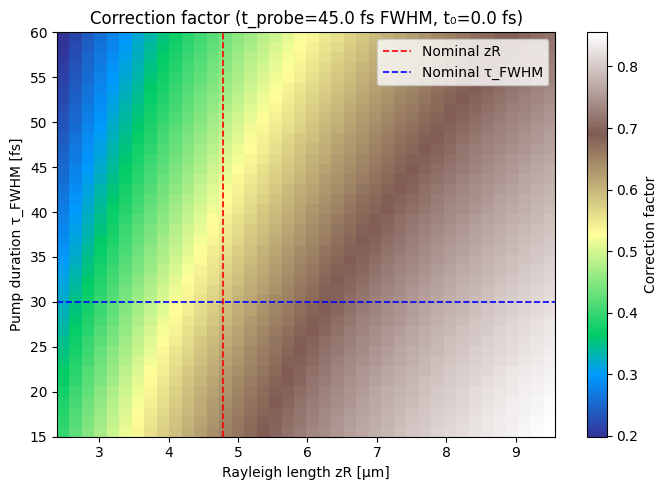

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.hermite import hermgauss
from scipy.special import wofz  # Faddeeva (stable for large complex args)

# -----------------------------
# Constants
# -----------------------------
c   = 299_792_458.0
lambda_IR = 800e-9  # wavelength [m]

# -----------------------------
# Universal stable F(chi, chi0, rho)
# -----------------------------
def F_of_stable(chi: float, chi0: float, rho: float, n_nodes: int = 120) -> float:
    """
    Overflow-safe for all (chi, chi0, rho).
    Start from:
      S = exp(-z^2 - chi^2) * [ w(i(z+chi)) + w(i(-z+chi)) ],  z = rho*K - i*chi0
    Then:
      |S|^2 brings exp(-2 Re(z^2 + chi^2))
    Prefactor has exp(+2(chi^2 - chi0^2)).
    Using Re(z^2)=rho^2 K^2 - chi0^2 and chi^2 real, the big exponentials CANCEL,
    leaving a benign factor exp(-2*rho^2*K^2).
    We directly integrate:
      ∫ e^{-K^2} |S|^2 dK = ∫ e^{-2 rho^2 K^2} | w(i(z+chi)) + w(i(-z+chi)) |^2 dK
    and multiply by sqrt((1+2 rho^2)/3) * chi^2.
    """
    K, W = hermgauss(n_nodes)

    # Skip nodes that contribute < ~1e-305 to avoid unnecessary wofz calls and 0*inf issues
    # exp(-2*rho^2*K^2) < ~5e-309 when 2*rho^2*K^2 > ~710 (safe margin)
    mask = (2.0*(rho*rho)*(K*K) < 700.0)
    if not np.any(mask):
        return 0.0

    K = K[mask]; W = W[mask]
    z = rho*K - 1j*chi0
    a = 1j*( z + chi)   # i(z+chi)
    b = 1j*(-z + chi)   # i(-z+chi)

    Wsum = wofz(a) + wofz(b)              # complex, stable
    integrand = np.exp(-2.0*(rho*rho)*(K*K)) * (Wsum.real**2 + Wsum.imag**2)

    # Finite guard (shouldn't trigger, but keeps the map clean if any lib returns inf/nan)
    integrand = np.nan_to_num(integrand, nan=0.0, posinf=0.0, neginf=0.0)

    I = np.sum(W * integrand)
    pref = np.sqrt((1.0 + 2.0*rho*rho)/3.0) * (chi*chi)
    return pref * I

def compute_R(zR, T_FWHM, tau_FWHM, t0=0.0, n_nodes=120):
    # FWHM → 1/e^2 (your convention)
    T   = T_FWHM   * 2 / np.sqrt(2*np.log(2))
    tau = tau_FWHM * 2 / np.sqrt(2*np.log(2))

    sigma = np.sqrt((c*T)**2 + (c*tau)**2 / 2.0)
    chi   = 4.0 * zR / sigma
    chi0  = 2.0 * (c*t0) / sigma
    rho   = T / tau

    F_val = F_of_stable(chi, chi0, rho, n_nodes=n_nodes)
    R     = (np.sqrt(3.0*np.pi) / 4.0) * F_val
    R = float(np.real_if_close(R, tol=1e5))
    # Final safety: clamp any numerical garbage to 0
    if not np.isfinite(R):
        R = 0.0
    return R

# -----------------------------
# Parameters for scan
# -----------------------------
zR_nominal = 4.787e-6     # [m]
tau_nominal = 30e-15      # [s] (FWHM)
T_FWHM = 45e-15           # [s] (FWHM)
t0 = 0.0                  # [s]

# scan ranges ±100%
zR_values  = np.linspace(0.5*zR_nominal, 2.0*zR_nominal, 40)
tau_values = np.linspace(0.5*tau_nominal, 2.0*tau_nominal, 40)

# compute 2D map
R_map = np.zeros((len(tau_values), len(zR_values)))
for i, tauF in enumerate(tau_values):
    for j, zRval in enumerate(zR_values):
        R_map[i, j] = compute_R(zRval, T_FWHM, tauF, t0=t0, n_nodes=140)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7,5))
extent = [zR_values[0]*1e6, zR_values[-1]*1e6, tau_values[0]*1e15, tau_values[-1]*1e15]
plt.imshow(R_map, aspect='auto', origin='lower', extent=extent, cmap='terrain')
plt.colorbar(label="Correction factor")

# reference lines at nominal values
plt.axvline(zR_nominal*1e6, color="red", linestyle="--", linewidth=1.2, label="Nominal zR")
plt.axhline(tau_nominal*1e15, color="blue", linestyle="--", linewidth=1.2, label="Nominal τ_FWHM")

plt.xlabel("Rayleigh length zR [µm]")
plt.ylabel("Pump duration τ_FWHM [fs]")
plt.title(f"Correction factor (t_probe={T_FWHM*1e15:.1f} fs FWHM, t₀={t0*1e15:.1f} fs)")
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_2226023/1432326136.py:18: RuntimeWarning: invalid value encountered in multiply
  S = np.exp(-(z*z) - chi*chi) * (wofz(1j*(z + chi)) + wofz(1j*(-z + chi)))


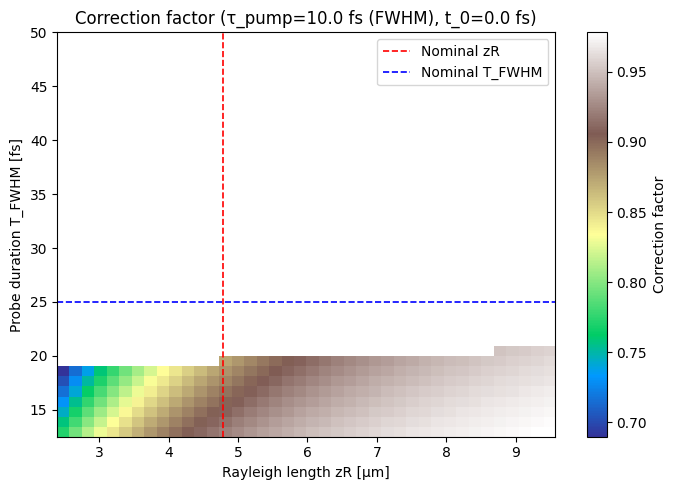

In [54]:
# -----------------------------
# Map 2: fixed pump τ_FWHM = 20 fs, vary probe T_FWHM and zR
# -----------------------------
zR_nominal = 4.787e-6       # [m]
T_nominal  = 25e-15         # probe duration FWHM [s] (scan center)
tau_fixed  = 10e-15         # pump duration FWHM [s] (fixed)
t0 = 0.0

# scan ranges ±100%
zR_values2 = np.linspace(0.5*zR_nominal, 2.0*zR_nominal, 40)
T_values   = np.linspace(0.5*T_nominal, 2.0*T_nominal, 40)

# compute 2D map: rows = T_FWHM, cols = zR
R_map_2 = np.zeros((len(T_values), len(zR_values2)))
for i, TF in enumerate(T_values):
    for j, zRval in enumerate(zR_values2):
        R_map_2[i, j] = compute_R(zRval, TF, tau_fixed, t0=t0, n_nodes=120)

# plot
plt.figure(figsize=(7,5))
extent2 = [zR_values2[0]*1e6, zR_values2[-1]*1e6, T_values[0]*1e15, T_values[-1]*1e15]
plt.imshow(R_map_2, aspect='auto', origin='lower', extent=extent2, cmap='terrain')
plt.colorbar(label="Correction factor")

# reference lines at nominal values
plt.axvline(zR_nominal*1e6, color="red", linestyle="--", linewidth=1.2, label="Nominal zR")
plt.axhline(T_nominal*1e15,  color="blue", linestyle="--", linewidth=1.2, label="Nominal T_FWHM")

plt.xlabel("Rayleigh length zR [µm]")
plt.ylabel("Probe duration T_FWHM [fs]")
plt.title(f"Correction factor (τ_pump={tau_fixed*1e15:.1f} fs (FWHM), t_0={t0*1e15:.1f} fs)")
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()
